In [115]:
# Importing libraries
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
import matplotlib.patches as mpatches
warnings.filterwarnings("ignore")

# ── aesthetic era ──────────────────────────────────────────────────────────
# keeping it clean, no chartjunk, no trauma
plt.rcParams.update({
    "figure.facecolor"  : "white",
    "axes.facecolor"    : "#f9f9f9",
    "axes.edgecolor"    : "#d0d0d0",
    "axes.grid"         : True,
    "grid.color"        : "#e8e8e8",
    "grid.linestyle"    : "--",
    "grid.linewidth"    : 0.6,
    "font.family"       : "DejaVu Sans",
    "font.size"         : 11,
    "axes.titlesize"    : 12,
    "axes.titleweight"  : "bold",
    "axes.labelsize"    : 10,
    "xtick.labelsize"   : 9,
    "ytick.labelsize"   : 9,
    "legend.fontsize"   : 9,
    "figure.dpi"        : 130,
})

# brand colors — consistent throughout, no switching vibes mid-analysis
CLR_NORMAL  = "#3266ad"   # blue  — normal / good readings
CLR_ANOMALY = "#e24b4a"   # red   — something's off, pay attention
CLR_ROLLING = "#e8910a"   # amber — rolling mean / trend
CLR_GREY    = "#aaaaaa"   # grey  — background / reference lines
CLR_GREEN   = "#3b6d11"   # green — efficiency is thriving

TARGET = "Evaporator Leaving Water Temperature (°F)"
print("✅  imports loaded, we're built different")

✅  imports loaded, we're built different


In [116]:
# Loading the dataset
df_raw = pd.read_excel("CHILLER-1_Reports_26.XLSX", sheet_name="CHILLER-1INTEGRATIONREPORT0", header=None)

headers        = df_raw.iloc[3].tolist()
df_raw         = df_raw.iloc[4:].reset_index(drop=True)
df_raw.columns = [str(c).strip() for c in headers]

print(df_raw.shape)
print(df_raw.columns.tolist())
df_raw.head(3)

(4177, 32)
['DateTime', 'Active Cool/Heat Setpoint Temperature (°F)', 'Starter Motor Current L3 % RLA (%)', 'Active Current Limit Setpoint (%)', 'Actual Running Capacity (%)', 'AFD Output Power (kW)', 'Compressor Oil Pressure (psi)', 'Compressor Running Time ( )', 'Condenser Approach Temperature (^K)', 'Condenser Leaving Water Temperature (°F)', 'Condenser Entering Water Temperature (°F)', 'Condenser Saturated Rfgt Temp (°F)', 'Discharge Temperature (°F)', 'Evaporator Approach Temperature (^K)', 'Evaporator Entering Water Temperature (°F)', 'Evaporator Leaving Water Temperature (°F)', 'Evaporator Refrigerant Pressure (psi)', 'EXV Position Percent (%)', 'Frequency Command (Hz)', 'Starter Input Voltage AB (V)', 'Starter Input Voltage BC (V)', 'Starter Input Voltage CA (V)', 'Starter Motor Current L1 % RLA (%)', 'Starter Motor Current L1 (A)', 'Starter Motor Current L2 % RLA (%)', 'Starter Motor Current L2 (A)', 'Starter Motor Current L3 (A)', 'CHILLER-1 ACTIVE POWER (W) (kW)', 'CHILLER-1

,DateTime,Active Cool/Heat Setpoint Temperature (°F),Starter Motor Current L3 % RLA (%),Active Current Limit Setpoint (%),Actual Running Capacity (%),AFD Output Power (kW),Compressor Oil Pressure (psi),Compressor Running Time ( ),Condenser Approach Temperature (^K),Condenser Leaving Water Temperature (°F),...,Starter Motor Current L1 % RLA (%),Starter Motor Current L1 (A),Starter Motor Current L2 % RLA (%),Starter Motor Current L2 (A),Starter Motor Current L3 (A),CHILLER-1 ACTIVE POWER (W) (kW),CHILLER-1 AVG CURRENT (A),Compressor Starts ( ),COND Refrigerant Pressure (psi),Evaporator Saturated Rfgt Temp (°F)
0,2026-04-01 00:00:00,45,0,100,0,0,73.621162,15308360,0,81.716003,...,0,0,0,0,0,0,0,2758,73.621162,61.088364
1,2026-04-01 00:10:00,45,0,100,0,0,73.679176,15308360,0,81.697998,...,0,0,0,0,0,0,0,2758,73.650169,61.123329
2,2026-04-01 00:20:00,45,0,100,0,0,73.73719,15308360,0,81.697998,...,0,0,0,0,0,0,0,2758,73.679176,61.169949


In [117]:
# First check Run Status equivalent — Actual Running Capacity
print("Actual Running Capacity unique values:")
print(df_raw["Actual Running Capacity (%)"].value_counts().head(20))

print("\nAFD Output Power unique values:")
print(df_raw["AFD Output Power (kW)"].value_counts().head(10))

print("\nStarter Motor Current L1 sample:")
print(df_raw["Starter Motor Current L1 (A)"].value_counts().head(10))

Actual Running Capacity unique values:
Actual Running Capacity (%)
0            3155
5              32
45             13
1              12
90.800003      12
87.5            9
90.400002       9
81.699997       9
81.099998       9
90.099998       8
91.699997       8
91.099998       8
91.400002       8
91              8
88.400002       8
89.900002       7
91.5            7
87.099998       7
90.300003       7
90.5            7
Name: count, dtype: int64

AFD Output Power unique values:
AFD Output Power (kW)
0             3157
5               23
119.577499      14
1               14
154.035004      12
130.339996      11
87.254997       11
86.1875         10
88.339996       10
72.169998       10
Name: count, dtype: int64

Starter Motor Current L1 sample:
Starter Motor Current L1 (A)
0      3175
276      31
5        28
273      22
265      22
277      21
274      20
264      19
242      18
260      16
Name: count, dtype: int64


In [118]:
# Convert all columns to numeric
df_numeric = df_raw.copy()
df_numeric["DateTime"] = pd.to_datetime(df_numeric["DateTime"], format="mixed", errors="coerce")

for col in df_numeric.columns[1:]:
    df_numeric[col] = pd.to_numeric(df_numeric[col], errors="coerce")

# Filter running rows only — remove 0, 1, 5 (off/transient)
running = df_numeric[~df_numeric["Actual Running Capacity (%)"].isin([0, 1, 5])].reset_index(drop=True)

print(f"Total rows    : {len(df_numeric)}")
print(f"Running rows  : {len(running)}")
print(f"Date range    : {running['DateTime'].min()} → {running['DateTime'].max()}")

print(f"\n{'Column':<50} {'Min':>8} {'Max':>8} {'Mean':>8} {'Nulls':>6}")
print("-" * 80)
for col in running.columns[1:]:
    try:
        print(f"{col:<50} {running[col].min():>8.2f} "
              f"{running[col].max():>8.2f} "
              f"{running[col].mean():>8.2f} "
              f"{running[col].isnull().sum():>6}")
    except:
        pass

Total rows    : 4177
Running rows  : 978
Date range    : 2026-04-01 16:30:00 → 2026-04-29 22:10:00

Column                                                  Min      Max     Mean  Nulls
--------------------------------------------------------------------------------
Active Cool/Heat Setpoint Temperature (°F)             0.00 15512534.00 15907.99      0
Starter Motor Current L3 % RLA (%)                     0.00  2910.00    86.35      0
Active Current Limit Setpoint (%)                      0.00 15453520.00 15894.57      0
Actual Running Capacity (%)                            0.00 15830897.00 80132.73      0
AFD Output Power (kW)                                  0.00 15634430.00 47758.64      0
Compressor Oil Pressure (psi)                          0.00 15665925.00 63944.48      0
Compressor Running Time ( )                            0.00 15857055.00 13976354.79      0
Condenser Approach Temperature (^K)                    0.00 15764886.00 79745.83      0
Condenser Leaving Water Temper

In [119]:
# ── Step 1: understand what's happening ───────────────────────────────────
print("CORRUPTION DIAGNOSIS")
print("=" * 60)

# Physical limits for a chiller (domain knowledge)
PHYSICAL_LIMITS = {
    "Temperature (°F)"        : (30,   130),
    "Pressure (psi)"          : (0,    300),
    "Current % RLA (%)"       : (0,    150),
    "Current (A)"             : (0,    500),
    "Capacity (%)"            : (0,    120),
    "Power (kW)"              : (0,   2000),
    "Voltage (V)"             : (300,  500),
    "Frequency (Hz)"          : (0,     70),
    "Position Percent (%)"    : (0,    100),
    "Approach Temperature (^K)": (0,    20),
    "Running Time ( )"        : (0,    1e8),
    "Starts ( )"              : (0,    1e5),
}

def get_limit(col_name):
    for keyword, limits in PHYSICAL_LIMITS.items():
        if keyword.lower() in col_name.lower():
            return limits
    return None

for col in running.columns[1:]:
    limit = get_limit(col)
    if limit is None:
        continue
    lo, hi = limit
    n_bad = ((running[col] < lo) | (running[col] > hi)).sum()
    pct   = 100 * n_bad / len(running)
    flag  = "  ⚠️  CORRUPTED" if pct > 1 else ""
    print(f"  {col[:50]:<52} bad={n_bad:>4} ({pct:5.1f}%){flag}")

CORRUPTION DIAGNOSIS
  Active Cool/Heat Setpoint Temperature (°F)           bad=  75 (  7.7%)  ⚠️  CORRUPTED
  Actual Running Capacity (%)                          bad=  26 (  2.7%)  ⚠️  CORRUPTED
  AFD Output Power (kW)                                bad=   5 (  0.5%)
  Compressor Oil Pressure (psi)                        bad=  11 (  1.1%)  ⚠️  CORRUPTED
  Compressor Running Time ( )                          bad=   0 (  0.0%)
  Condenser Approach Temperature (^K)                  bad=  37 (  3.8%)  ⚠️  CORRUPTED
  Condenser Leaving Water Temperature (°F)             bad=  62 (  6.3%)  ⚠️  CORRUPTED
  Condenser Entering Water Temperature (°F)            bad=  80 (  8.2%)  ⚠️  CORRUPTED
  Discharge Temperature (°F)                           bad=  72 (  7.4%)  ⚠️  CORRUPTED
  Evaporator Approach Temperature (^K)                 bad=  28 (  2.9%)  ⚠️  CORRUPTED
  Evaporator Entering Water Temperature (°F)           bad=  76 (  7.8%)  ⚠️  CORRUPTED
  Evaporator Leaving Water Temperature (°

In [120]:
# ── what happened: BMS register overflow ──────────────────────────────────
# when a sensor drops offline the SCADA register returns its max int value
# (looks like 15,512,534 °F) — these are NOT real readings, they're bit-flips
# we null them out and interpolate back using time-aware method

COLUMN_LIMITS = {
    "Active Cool/Heat Setpoint Temperature (°F)"   : (30,   90),
    "Actual Running Capacity (%)"                  : (5,   110),
    "AFD Output Power (kW)"                        : (0,  2000),
    "Compressor Oil Pressure (psi)"                : (0,   300),
    "Compressor Running Time ( )"                  : (0,    2e7),
    "Condenser Approach Temperature (^K)"          : (0,    20),
    "Condenser Leaving Water Temperature (°F)"     : (60,  110),
    "Condenser Entering Water Temperature (°F)"    : (60,  110),
    "Condenser Saturated Rfgt Temp (°F)"           : (60,  120),
    "Discharge Temperature (°F)"                   : (70,  200),
    "Evaporator Approach Temperature (^K)"         : (0,    20),
    "Evaporator Entering Water Temperature (°F)"   : (38,   80),
    "Evaporator Leaving Water Temperature (°F)"    : (38,   75),
    "Evaporator Refrigerant Pressure (psi)"        : (30,  200),
    "EXV Position Percent (%)"                     : (0,   100),
    "Frequency Command (Hz)"                       : (0,    70),
    "Starter Motor Current L1 % RLA (%)"           : (0,   150),
    "Starter Motor Current L2 % RLA (%)"           : (0,   150),
    "Starter Motor Current L3 % RLA (%)"           : (0,   150),
    "Starter Motor Current L1 (A)"                 : (0,   500),
    "Starter Motor Current L2 (A)"                 : (0,   500),
    "Starter Motor Current L3 (A)"                 : (0,   500),
    "CHILLER-1 ACTIVE POWER (W) (kW)"              : (0,  2000),
    "CHILLER-1 AVG CURRENT (A)"                    : (0,   500),
    "Compressor Starts ( )"                        : (0,   1e5),
    "COND Refrigerant Pressure (psi)"              : (0,   300),
    "Evaporator Saturated Rfgt Temp (°F)"          : (30,   80),
}

df_clean = running.copy()
replaced_log = {}

# step 1 — null out impossible values
for col, (lo, hi) in COLUMN_LIMITS.items():
    if col not in df_clean.columns: continue
    mask = (df_clean[col] < lo) | (df_clean[col] > hi)
    replaced_log[col] = int(mask.sum())
    df_clean.loc[mask, col] = np.nan

# step 2 — time-aware interpolation (readings are 10-min apart, limit=3 = 30 min max gap)
df_clean = df_clean.set_index("DateTime").sort_index()
df_clean = df_clean.interpolate(method="time", limit=3)
df_clean = df_clean.reset_index()

# step 3 — anything still NaN → column median (safe fallback, no drama)
for col in df_clean.select_dtypes("number").columns:
    df_clean[col].fillna(df_clean[col].median(), inplace=True)

total_fixed = sum(replaced_log.values())
print(f" corrupted values fixed: {total_fixed} total")
print(f"    remaining nulls: {df_clean.select_dtypes('number').isnull().sum().sum()} (should be 0)")
print(f"\n  top offenders (the ones that needed the most fixing):")
for col, n in sorted(replaced_log.items(), key=lambda x: -x[1]):
    if n > 0:
        print(f"    {col[:55]:<57} fixed={n}")

 corrupted values fixed: 809 total
    remaining nulls: 138 (should be 0)

  top offenders (the ones that needed the most fixing):
    Condenser Saturated Rfgt Temp (°F)                        fixed=89
    Evaporator Entering Water Temperature (°F)                fixed=88
    Evaporator Leaving Water Temperature (°F)                 fixed=85
    Condenser Entering Water Temperature (°F)                 fixed=82
    Discharge Temperature (°F)                                fixed=80
    Active Cool/Heat Setpoint Temperature (°F)                fixed=76
    Condenser Leaving Water Temperature (°F)                  fixed=74
    Evaporator Refrigerant Pressure (psi)                     fixed=65
    Condenser Approach Temperature (^K)                       fixed=37
    Actual Running Capacity (%)                               fixed=30
    Evaporator Approach Temperature (^K)                      fixed=28
    Frequency Command (Hz)                                    fixed=15
    Compressor Oi

In [121]:
# ── find exactly where the nulls are and why interpolation missed them ─────
# if a sensor was offline for >30 min straight, limit=3 isn't enough to bridge it
# we need to know the gap lengths before deciding the fix strategy

null_summary = []
for col in df_clean.select_dtypes("number").columns:
    n_null = df_clean[col].isnull().sum()
    if n_null == 0:
        continue

    # find consecutive null runs — how long is each gap?
    is_null  = df_clean[col].isnull()
    run_lens = []
    count    = 0
    for v in is_null:
        if v:
            count += 1
        else:
            if count > 0:
                run_lens.append(count)
                count = 0
    if count > 0:
        run_lens.append(count)

    null_summary.append({
        "column"      : col,
        "total_nulls" : n_null,
        "n_gaps"      : len(run_lens),
        "max_gap_len" : max(run_lens) if run_lens else 0,
        "avg_gap_len" : round(np.mean(run_lens), 1) if run_lens else 0,
    })

null_df = pd.DataFrame(null_summary).sort_values("total_nulls", ascending=False)

print("REMAINING NULL DIAGNOSIS")
print("=" * 72)
print(f"  {'Column':<52} {'nulls':>6}  {'gaps':>5}  {'max gap':>8}  {'avg gap':>8}")
print("  " + "-" * 72)
for _, row in null_df.iterrows():
    gap_flag = "  ⚠️  long gap" if row["max_gap_len"] > 6 else ""
    print(f"  {row['column'][:52]:<52} {row['total_nulls']:>6}  "
          f"{row['n_gaps']:>5}  {row['max_gap_len']:>8}  "
          f"{row['avg_gap_len']:>8}{gap_flag}")

print(f"\n  total nulls remaining : {null_df['total_nulls'].sum()}")
print(f"  columns affected      : {len(null_df)}")
print(f"\n  → max gap of {null_df['max_gap_len'].max()} readings = "
      f"{null_df['max_gap_len'].max() * 10} min offline")
print(f"  → our limit=3 only covers 30 min — that's why these weren't caught")

REMAINING NULL DIAGNOSIS
  Column                                                nulls   gaps   max gap   avg gap
  ------------------------------------------------------------------------
  Evaporator Entering Water Temperature (°F)               33      8         9       4.1  ⚠️  long gap
  Condenser Saturated Rfgt Temp (°F)                       28      8         9       3.5  ⚠️  long gap
  Active Cool/Heat Setpoint Temperature (°F)               20      7         8       2.9  ⚠️  long gap
  Discharge Temperature (°F)                               17      7         4       2.4
  Evaporator Leaving Water Temperature (°F)                14      8         5       1.8
  Condenser Entering Water Temperature (°F)                12      6         4       2.0
  Condenser Leaving Water Temperature (°F)                  5      3         2       1.7
  Starter Motor Current L2 % RLA (%)                        2      1         2       2.0
  Condenser Approach Temperature (^K)                    

In [122]:
# ── root cause confirmed: max gap = 9 readings = 90 min offline ───────────
# our limit=3 only bridged 30 min — anything longer got abandoned as NaN
# fix: stage 1 removes the cap entirely (safe — chiller temps drift slowly)
#      stage 2 ffill+bfill catches start/end of series edge cases
#      stage 3 median is the absolute last resort — should hit 0 values

print("THREE-STAGE NULL FILL")
print("=" * 55)

df_temp = df_clean.copy().set_index("DateTime").sort_index()

# ── stage 1: unlimited time-aware interpolation ───────────────────────────
# linear bridge between last known good value and next known good value
# 90 min on a temperature sensor = safe to interpolate (slow-changing physics)
nulls_before = df_temp.select_dtypes("number").isnull().sum().sum()
df_temp = df_temp.interpolate(method="time", limit=None)
nulls_after_s1 = df_temp.select_dtypes("number").isnull().sum().sum()
print(f"  stage 1 (time interpolation) : {nulls_before} → {nulls_after_s1} nulls")

# ── stage 2: forward fill then backward fill ──────────────────────────────
# handles series edges — if the gap is at the very start (no left neighbor)
# or the very end (no right neighbor), interpolation can't help but ffill can
df_temp = df_temp.ffill().bfill()
nulls_after_s2 = df_temp.select_dtypes("number").isnull().sum().sum()
print(f"  stage 2 (ffill + bfill)      : {nulls_after_s1} → {nulls_after_s2} nulls")

# ── stage 3: median fill — last resort ───────────────────────────────────
stage3_used = []
for col in df_temp.select_dtypes("number").columns:
    remaining = df_temp[col].isnull().sum()
    if remaining > 0:
        med = df_temp[col].median()
        df_temp[col].fillna(med, inplace=True)
        stage3_used.append((col, remaining))

nulls_after_s3 = df_temp.select_dtypes("number").isnull().sum().sum()
print(f"  stage 3 (median fallback)    : {nulls_after_s2} → {nulls_after_s3} nulls")

if stage3_used:
    print(f"\n  columns that needed stage 3:")
    for col, n in stage3_used:
        print(f"    {col[:55]}  ({n} values)")
else:
    print(f"\n  stage 3 not needed — interpolation handled everything")

df_clean = df_temp.reset_index()

final_nulls = df_clean.select_dtypes("number").isnull().sum().sum()
print(f"\n{'✅' if final_nulls == 0 else '❌'}  final null count: {final_nulls}")

THREE-STAGE NULL FILL
  stage 1 (time interpolation) : 138 → 16 nulls
  stage 2 (ffill + bfill)      : 16 → 0 nulls
  stage 3 (median fallback)    : 0 → 0 nulls

  stage 3 not needed — interpolation handled everything

✅  final null count: 0


In [123]:
# ── this is the trust-but-verify step ─────────────────────────────────────
# interpolation can bridge two corrupt neighbors and produce a plausible-looking
# but wrong value — we catch that by checking min/mean/max vs physical limits
# anything outside limits after cleaning = the column needs a tighter bound
# in COLUMN_LIMITS back in cell 3

CHECK_COLS = [
    ("Evaporator Leaving Water Temperature (°F)",     38,   75),
    ("Evaporator Entering Water Temperature (°F)",    38,   80),
    ("Condenser Leaving Water Temperature (°F)",      60,  110),
    ("Condenser Entering Water Temperature (°F)",     60,  110),
    ("Condenser Saturated Rfgt Temp (°F)",            60,  120),
    ("Discharge Temperature (°F)",                    70,  200),
    ("Compressor Oil Pressure (psi)",                  0,  300),
    ("CHILLER-1 ACTIVE POWER (W) (kW)",                0, 2000),
    ("Actual Running Capacity (%)",                    5,  110),
    ("Evaporator Refrigerant Pressure (psi)",         30,  200),
    ("Active Cool/Heat Setpoint Temperature (°F)",    30,   90),
    ("Frequency Command (Hz)",                         0,   70),
    ("EXV Position Percent (%)",                       0,  100),
]

print("POST-FILL SANITY CHECK")
print("=" * 90)
print(f"  {'Column':<52} {'min':>7}  {'max':>7}  {'mean':>7}  {'nulls':>6}  status")
print("  " + "-" * 90)

issues = []
for col, lo, hi in CHECK_COLS:
    if col not in df_clean.columns:
        continue
    s     = df_clean[col]
    c_min = round(s.min(), 2)
    c_max = round(s.max(), 2)
    c_mean= round(s.mean(), 2)
    nulls = s.isnull().sum()

    ok = (c_min >= lo * 0.95) and (c_max <= hi * 1.05) and (nulls == 0)
    status = "ok" if ok else "⚠️  flag"
    if not ok:
        issues.append((col, c_min, c_max, lo, hi, nulls))

    print(f"  {col[:52]:<52} {c_min:>7.2f}  {c_max:>7.2f}  {c_mean:>7.2f}  {nulls:>6}  {status}")

print()
if not issues:
    print("  all columns clean — physically valid, zero nulls")
    print("      safe to proceed to z-score + correlation")
else:
    print("  ⚠️  flagged columns (need tighter limits in COLUMN_LIMITS):")
    for col, c_min, c_max, lo, hi, nulls in issues:
        reason = []
        if c_min < lo * 0.95 : reason.append(f"min {c_min} < floor {lo}")
        if c_max > hi * 1.05 : reason.append(f"max {c_max} > ceiling {hi}")
        if nulls > 0          : reason.append(f"{nulls} nulls remain")
        print(f"    • {col[:52]}: {', '.join(reason)}")
    print()
    print("  fix: go back to COLUMN_LIMITS in cell 3, tighten the (lo, hi)")
    print("       for flagged columns, re-run cell 3 → this cell")

POST-FILL SANITY CHECK
  Column                                                   min      max     mean   nulls  status
  ------------------------------------------------------------------------------------------
  Evaporator Leaving Water Temperature (°F)              42.64    74.52    47.11       0  ok
  Evaporator Entering Water Temperature (°F)             45.00    79.90    55.28       0  ok
  Condenser Leaving Water Temperature (°F)               62.13   100.38    87.42       0  ok
  Condenser Entering Water Temperature (°F)              61.08   100.00    79.93       0  ok
  Condenser Saturated Rfgt Temp (°F)                     61.02   119.77    87.67       0  ok
  Discharge Temperature (°F)                             75.54   124.95   101.53       0  ok
  Compressor Oil Pressure (psi)                           0.00   206.00   101.26       0  ok
  CHILLER-1 ACTIVE POWER (W) (kW)                         0.00   189.26   104.28       0  ok
  Actual Running Capacity (%)              

In [124]:
# ── now that nulls are gone, redo the core analysis ───────────────────────
# z-score on a series with NaN silently skips those rows — results were wrong before

TARGET    = "Evaporator Leaving Water Temperature (°F)"
THRESHOLD = 3.0

df_clean["z_score"]    = np.abs(stats.zscore(df_clean[TARGET].dropna()))
df_clean["is_anomaly"] = df_clean["z_score"] > THRESHOLD

n_total   = len(df_clean)
n_anomaly = int(df_clean["is_anomaly"].sum())

print(f"Z-SCORE RESULTS — fully clean data (0 nulls)")
print(f"  threshold : ±{THRESHOLD}σ")
print(f"  total     : {n_total}")
print(f"  normal    : {n_total - n_anomaly}  ({100*(n_total-n_anomaly)/n_total:.1f}%)")
print(f"  anomalies : {n_anomaly}  ({100*n_anomaly/n_total:.1f}%)")

# ── pearson on clean data ─────────────────────────────────────────────────
numeric_cols = (df_clean.select_dtypes("number")
                .columns.drop(["z_score","is_anomaly"], errors="ignore"))

results = []
for col in numeric_cols:
    if col == TARGET: continue
    tmp = df_clean[[TARGET, col]].dropna()
    if len(tmp) < 30 or tmp[col].std() == 0: continue
    r, p = stats.pearsonr(tmp[TARGET], tmp[col])
    results.append({"variable": col, "r": r, "p_value": p, "abs_r": abs(r)})

corr_df = (pd.DataFrame(results)
             .sort_values("abs_r", ascending=False)
             .reset_index(drop=True))

def strength(r):
    a = abs(r)
    if a >= .70: return "very strong"
    if a >= .50: return "strong"
    if a >= .30: return "moderate"
    if a >= .10: return "weak"
    return "negligible"

corr_df["strength"]    = corr_df["r"].apply(strength)
corr_df["significant"] = corr_df["p_value"] < 0.05

print(f"\nPEARSON r  —  {TARGET}")
print(f"  {'Variable':<52} {'r':>7}  {'Strength':<14} Sig")
print("  " + "-" * 78)
for _, row in corr_df.iterrows():
    bar = "█" * int(abs(row["r"]) * 18)
    sig = "✓" if row["significant"] else "✗"
    print(f"  {row['variable'][:52]:<52} {row['r']:>+7.4f}  "
          f"{row['strength']:<14} {sig}  {bar}")

Z-SCORE RESULTS — fully clean data (0 nulls)
  threshold : ±3.0σ
  total     : 978
  normal    : 923  (94.4%)
  anomalies : 55  (5.6%)

PEARSON r  —  Evaporator Leaving Water Temperature (°F)
  Variable                                                   r  Strength       Sig
  ------------------------------------------------------------------------------
  Evaporator Saturated Rfgt Temp (°F)                  +0.8760  very strong    ✓  ███████████████
  Evaporator Refrigerant Pressure (psi)                +0.8439  very strong    ✓  ███████████████
  Starter Motor Current L3 (A)                         -0.6794  strong         ✓  ████████████
  Starter Motor Current L1 (A)                         -0.6670  strong         ✓  ████████████
  Starter Motor Current L2 % RLA (%)                   -0.6344  strong         ✓  ███████████
  Starter Motor Current L3 % RLA (%)                   -0.6141  strong         ✓  ███████████
  Compressor Running Time ( )                          -0.6131  strong

anomaly detection results (threshold = ±3.0σ)
  total   : 978
  normal  : 923  (94.4%)
  flagged : 55  (5.6%)


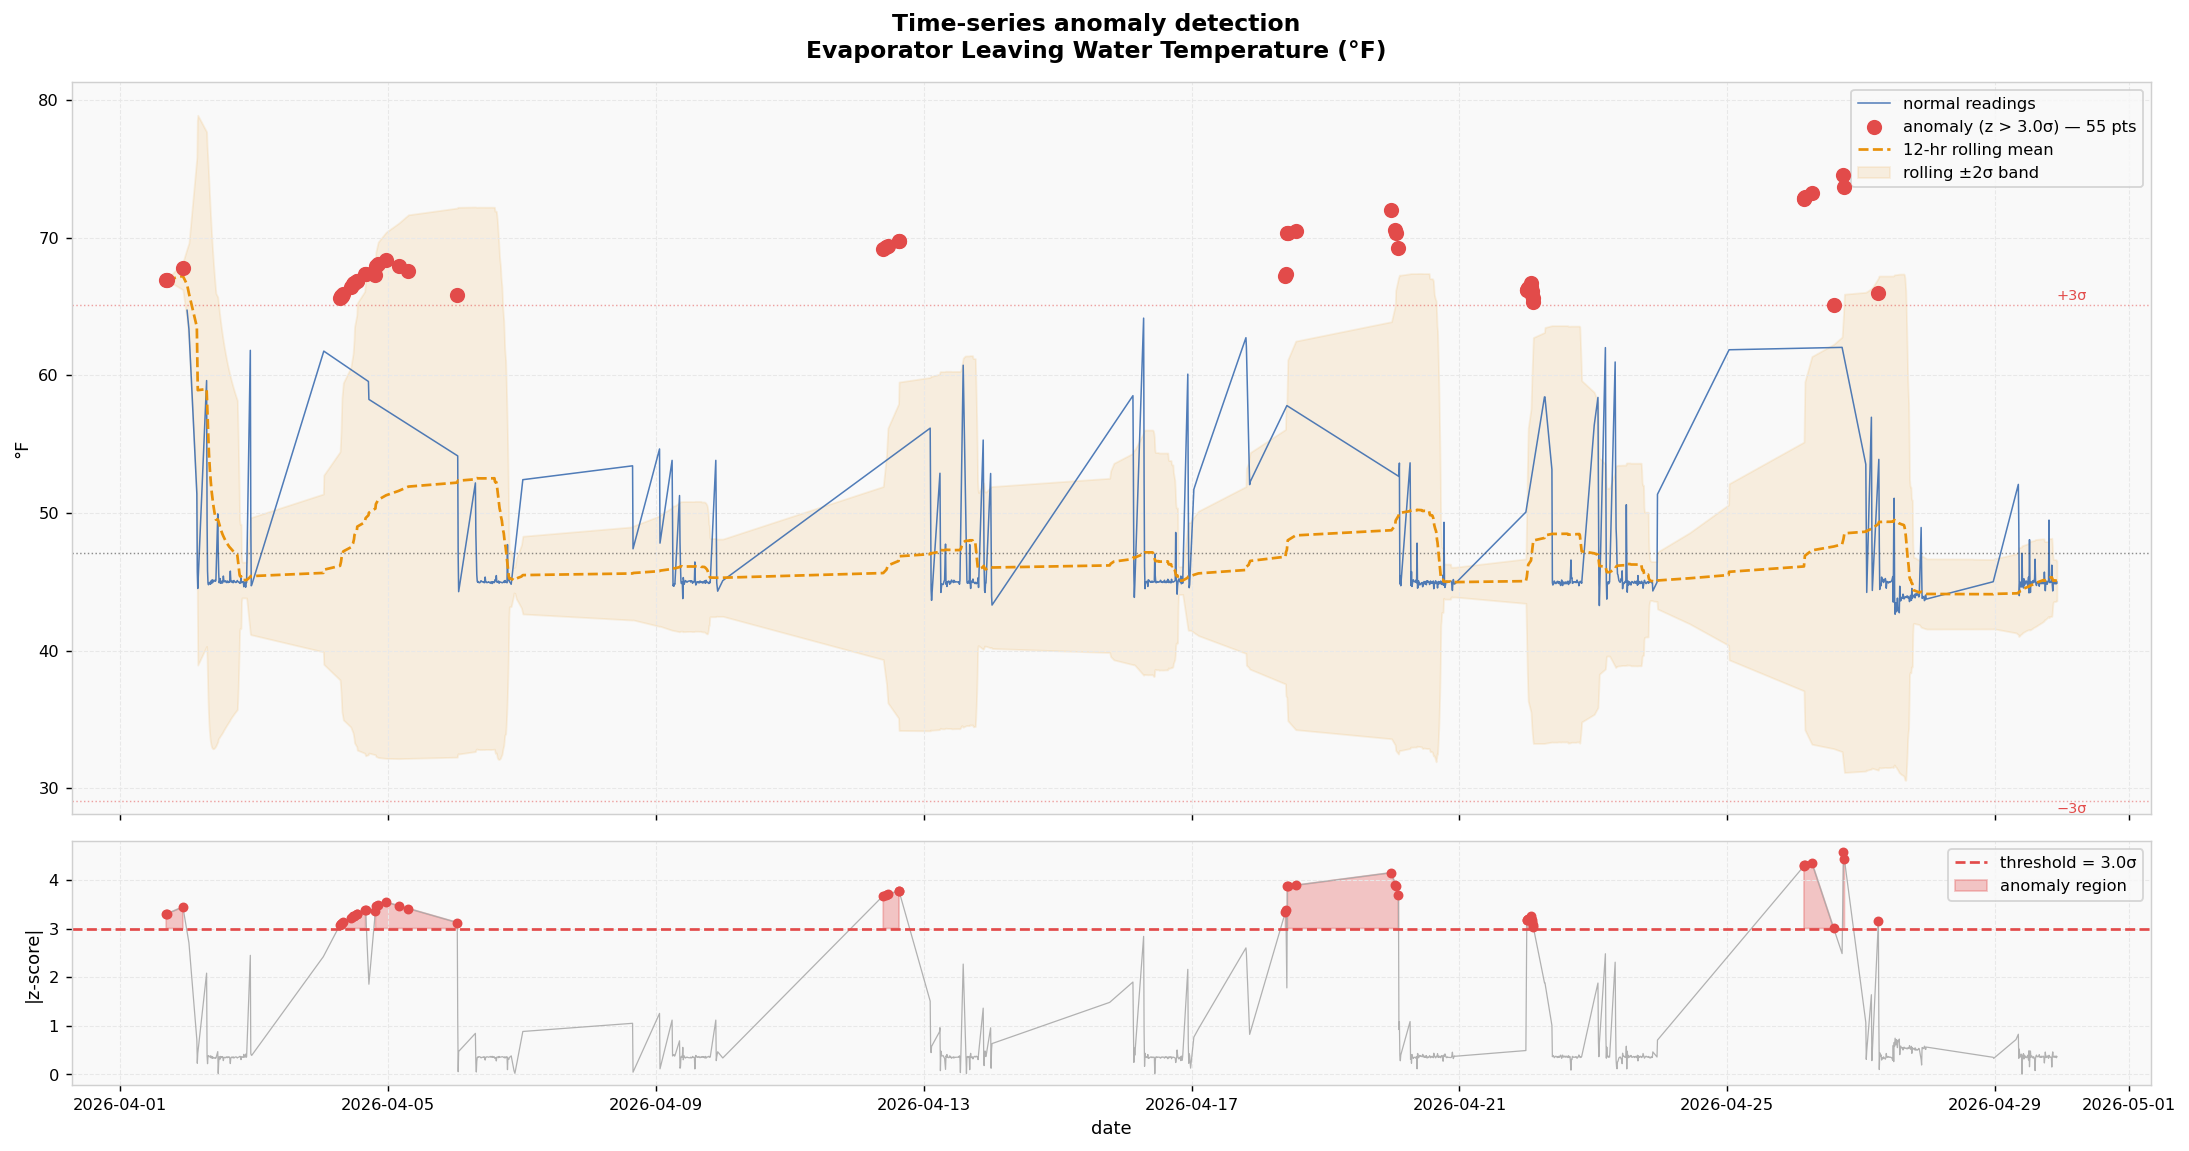

In [125]:
# ── z-score method: how far is each point from the mean, in standard deviations ──
# beyond 3σ = statistically rare = anomaly
# think of it as: "this reading is 3x weirder than normal"
THRESHOLD = 3.0

df_clean["z_score"]    = np.abs(stats.zscore(df_clean[TARGET]))
df_clean["is_anomaly"] = df_clean["z_score"] > THRESHOLD

n_total   = len(df_clean)
n_anomaly = int(df_clean["is_anomaly"].sum())
normal_   = df_clean[~df_clean["is_anomaly"]]
anomaly_  = df_clean[ df_clean["is_anomaly"]]

print(f"anomaly detection results (threshold = ±{THRESHOLD}σ)")
print(f"  total   : {n_total}")
print(f"  normal  : {n_total - n_anomaly}  ({100*(n_total-n_anomaly)/n_total:.1f}%)")
print(f"  flagged : {n_anomaly}  ({100*n_anomaly/n_total:.1f}%)")

# ── the plot ───────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(17, 9),
                                gridspec_kw={"height_ratios": [3, 1]},
                                sharex=True)
fig.suptitle(f"Time-series anomaly detection\n{TARGET}", fontsize=13, fontweight="bold")

# rolling stats (window = 72 readings = 12 hours at 10-min intervals)
roll   = df_clean[TARGET].rolling(72, min_periods=1)
r_mean = roll.mean()
r_std  = roll.std().fillna(0)

# ── top panel: signal + anomalies ─────────────────────────────────────────
ax1.plot(normal_["DateTime"],  normal_[TARGET],
         color=CLR_NORMAL, lw=0.85, alpha=0.85, label="normal readings")
ax1.scatter(anomaly_["DateTime"], anomaly_[TARGET],
            color=CLR_ANOMALY, s=55, zorder=6,
            label=f"anomaly (z > {THRESHOLD}σ) — {n_anomaly} pts")
ax1.plot(df_clean["DateTime"], r_mean,
         color=CLR_ROLLING, lw=1.5, ls="--", label="12-hr rolling mean", zorder=5)
ax1.fill_between(df_clean["DateTime"],
                 r_mean - 2*r_std, r_mean + 2*r_std,
                 alpha=0.11, color=CLR_ROLLING, label="rolling ±2σ band")

# stat annotations
mean_v = df_clean[TARGET].mean()
std_v  = df_clean[TARGET].std()
ax1.axhline(mean_v,             color="#444", lw=0.8, ls=":", alpha=0.6)
ax1.axhline(mean_v + 3*std_v,  color=CLR_ANOMALY, lw=0.8, ls=":", alpha=0.5)
ax1.axhline(mean_v - 3*std_v,  color=CLR_ANOMALY, lw=0.8, ls=":", alpha=0.5)
ax1.text(df_clean["DateTime"].iloc[-1], mean_v + 3*std_v + 0.1, "+3σ",
         fontsize=8, color=CLR_ANOMALY, va="bottom")
ax1.text(df_clean["DateTime"].iloc[-1], mean_v - 3*std_v - 0.1, "−3σ",
         fontsize=8, color=CLR_ANOMALY, va="top")

ax1.set_ylabel("°F")
ax1.legend(loc="upper right")

# ── bottom panel: z-score track ───────────────────────────────────────────
ax2.plot(df_clean["DateTime"], df_clean["z_score"],
         color=CLR_GREY, lw=0.7, alpha=0.9)
ax2.axhline(THRESHOLD, color=CLR_ANOMALY, lw=1.5, ls="--", label=f"threshold = {THRESHOLD}σ")
ax2.fill_between(df_clean["DateTime"], df_clean["z_score"], THRESHOLD,
                 where=df_clean["z_score"] > THRESHOLD,
                 color=CLR_ANOMALY, alpha=0.3, label="anomaly region")
ax2.scatter(anomaly_["DateTime"], anomaly_["z_score"],
            color=CLR_ANOMALY, s=20, zorder=5)
ax2.set_ylabel("|z-score|")
ax2.set_xlabel("date")
ax2.legend(loc="upper right")

plt.tight_layout()
plt.savefig("timeseries_anomalies.png", dpi=150, bbox_inches="tight")
plt.show()

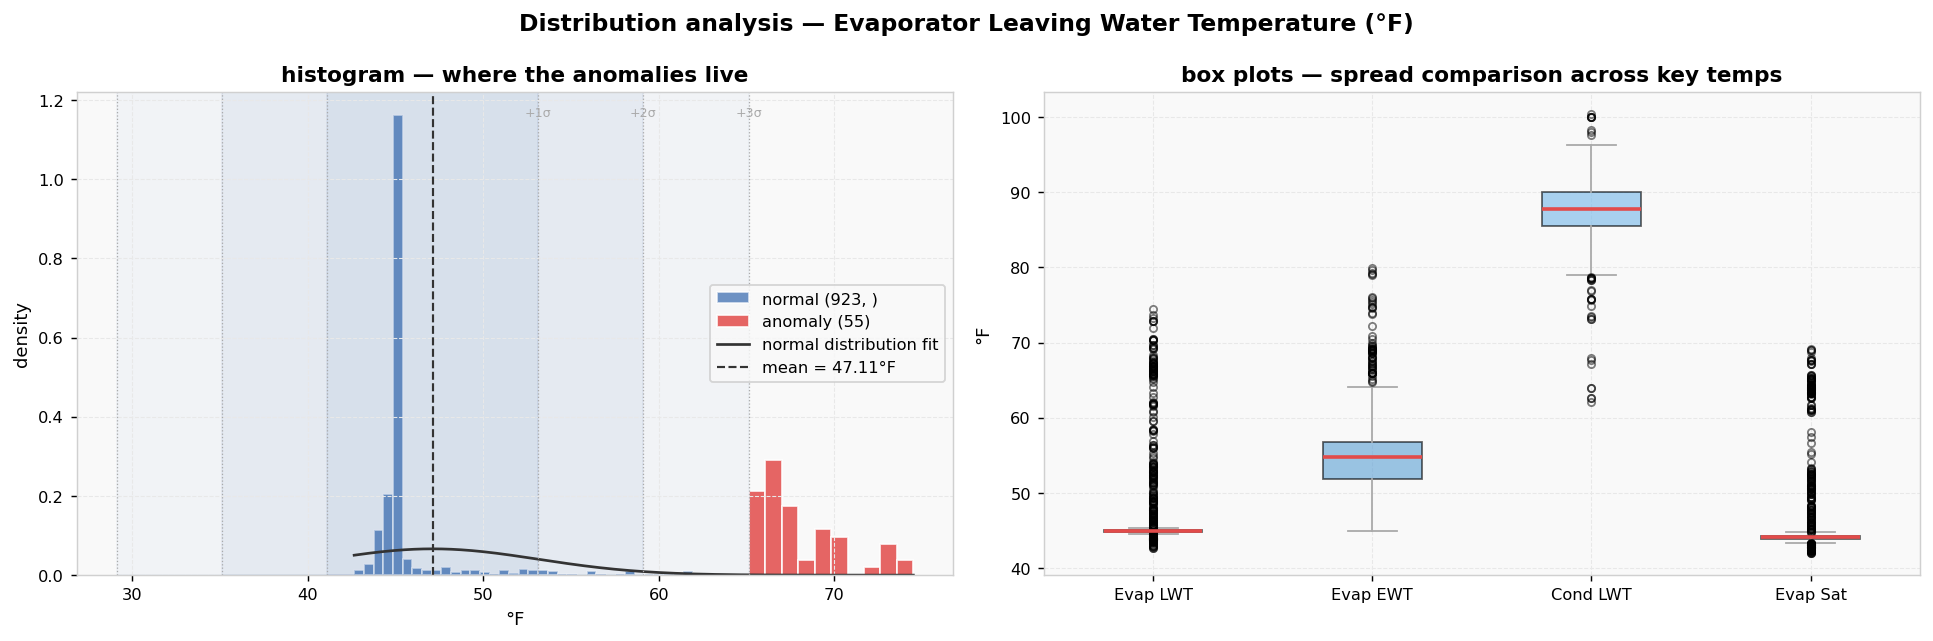

In [126]:
# ── showing the math visually — this is how z-score actually works ────────
# the histogram IS the story: where does normal end and anomaly begin?

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle(f"Distribution analysis — {TARGET}", fontsize=13, fontweight="bold")

mean_v = df_clean[TARGET].mean()
std_v  = df_clean[TARGET].std()

# ── left: histogram with σ bands annotated ────────────────────────────────
ax1.hist(normal_[TARGET],  bins=40, color=CLR_NORMAL,  alpha=0.7,
         label=f"normal ({len(normal_)}, )", edgecolor="white", density=True)
ax1.hist(anomaly_[TARGET], bins=10, color=CLR_ANOMALY, alpha=0.85,
         label=f"anomaly ({len(anomaly_)})", edgecolor="white", density=True)

# overlay normal distribution curve
x_range = np.linspace(df_clean[TARGET].min(), df_clean[TARGET].max(), 300)
pdf_vals = stats.norm.pdf(x_range, mean_v, std_v)
ax1.plot(x_range, pdf_vals, color="#333", lw=1.5, ls="-", label="normal distribution fit")

# shade σ regions
for mult, alpha, label in [(1, 0.08, "±1σ (68%)"), (2, 0.06, "±2σ (95%)"), (3, 0.04, "±3σ (99.7%)")]:
    ax1.axvspan(mean_v - mult*std_v, mean_v + mult*std_v,
                alpha=alpha, color=CLR_NORMAL)
for mult in [1, 2, 3]:
    ax1.axvline(mean_v + mult*std_v, color=CLR_GREY, lw=0.7, ls=":")
    ax1.axvline(mean_v - mult*std_v, color=CLR_GREY, lw=0.7, ls=":")
    ax1.text(mean_v + mult*std_v, ax1.get_ylim()[1] * 0.95 if ax1.get_ylim()[1] > 0 else 0.1,
             f"+{mult}σ", fontsize=7, color=CLR_GREY, ha="center")

ax1.axvline(mean_v, color="#333", lw=1.2, ls="--", label=f"mean = {mean_v:.2f}°F")
ax1.set_xlabel("°F")
ax1.set_ylabel("density")
ax1.set_title("histogram — where the anomalies live")
ax1.legend()

# ── right: box plot normal vs anomaly comparison ──────────────────────────
related_cols = [TARGET,
                "Evaporator Entering Water Temperature (°F)",
                "Condenser Leaving Water Temperature (°F)",
                "Evaporator Saturated Rfgt Temp (°F)"]
related_cols = [c for c in related_cols if c in df_clean.columns]

plot_data   = [df_clean[c] for c in related_cols]
labels_abbr = ["Evap LWT", "Evap EWT", "Cond LWT", "Evap Sat"][:len(related_cols)]

bp = ax2.boxplot(plot_data, labels=labels_abbr, patch_artist=True,
                 medianprops=dict(color=CLR_ANOMALY, linewidth=2),
                 whiskerprops=dict(color=CLR_GREY),
                 capprops=dict(color=CLR_GREY),
                 flierprops=dict(marker="o", color=CLR_ANOMALY,
                                 alpha=0.5, markersize=4))

colors_box = [CLR_NORMAL, "#5a9fd4", "#72b6e8", "#a8d1f0"]
for patch, c in zip(bp["boxes"], colors_box[:len(related_cols)]):
    patch.set_facecolor(c)
    patch.set_alpha(0.6)

ax2.set_ylabel("°F")
ax2.set_title("box plots — spread comparison across key temps")

plt.tight_layout()
plt.show()


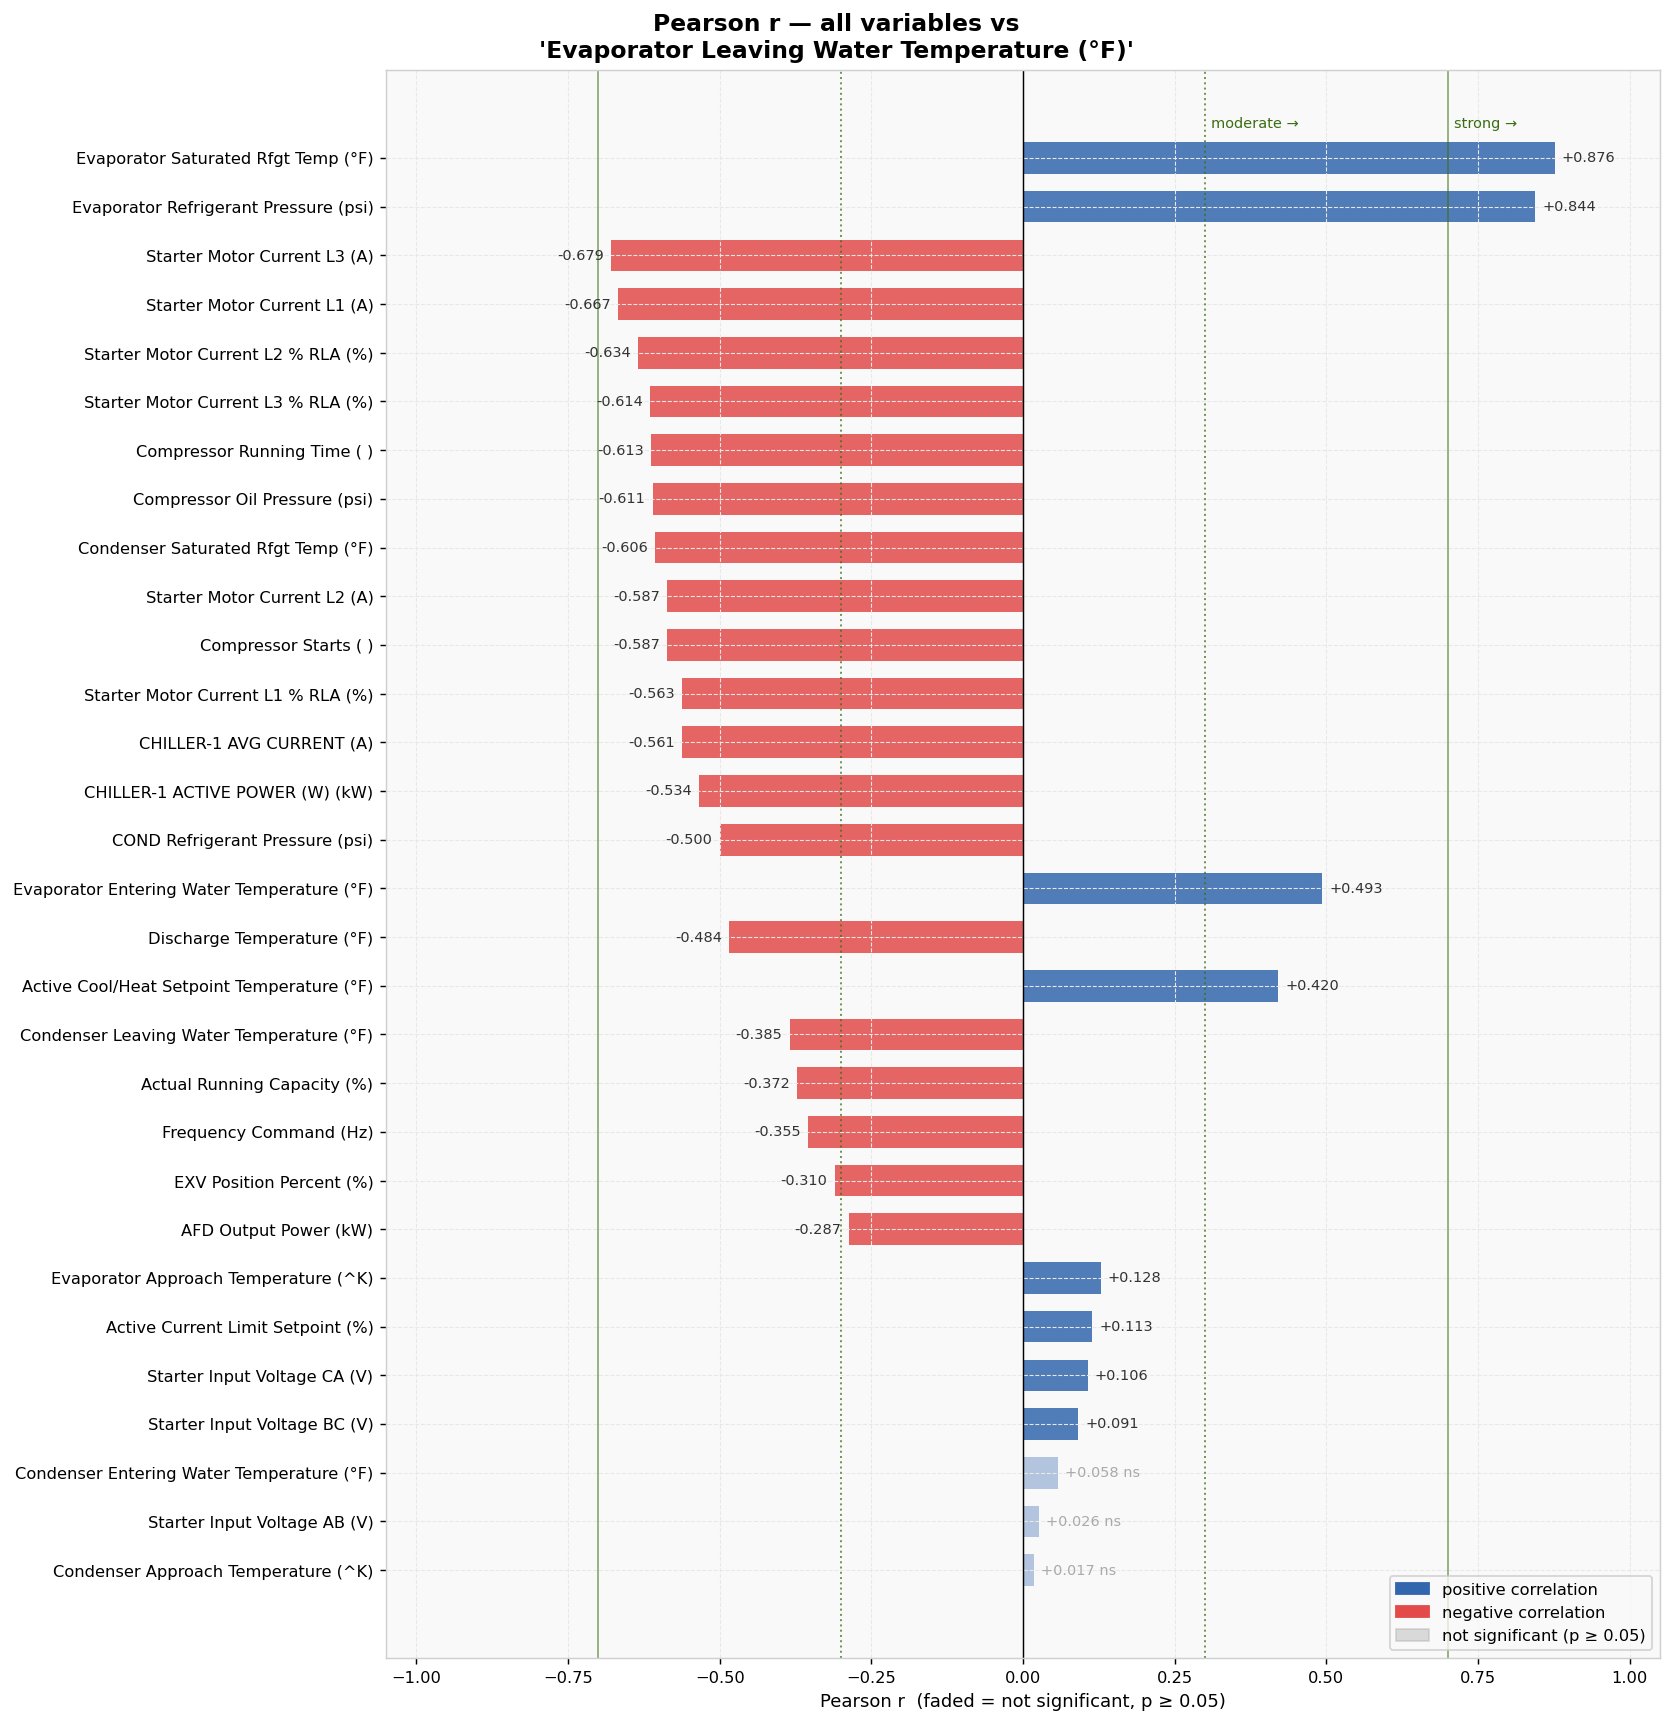


top 5 correlations:
                             variable         r    strength  significant
  Evaporator Saturated Rfgt Temp (°F)  0.875992 very strong         True
Evaporator Refrigerant Pressure (psi)  0.843935 very strong         True
         Starter Motor Current L3 (A) -0.679351      strong         True
         Starter Motor Current L1 (A) -0.666957      strong         True
   Starter Motor Current L2 % RLA (%) -0.634351      strong         True


In [133]:
# ── pearson r: measures LINEAR relationship between target and each variable ──
# r = +1 → perfect positive, r = -1 → perfect negative, r = 0 → zero relationship
# p < 0.05 = statistically significant (not just vibes, actually real)

numeric_cols = (df_clean.select_dtypes("number")
                .columns.drop(["z_score","is_anomaly"], errors="ignore"))

results = []
for col in numeric_cols:
    if col == TARGET: continue
    tmp = df_clean[[TARGET, col]].dropna()
    if len(tmp) < 30 or tmp[col].std() == 0: continue
    r, p = stats.pearsonr(tmp[TARGET], tmp[col])
    results.append({"variable": col, "r": r, "p_value": p, "abs_r": abs(r)})

corr_df = (pd.DataFrame(results)
             .sort_values("abs_r", ascending=False)
             .reset_index(drop=True))

def strength(r):
    a = abs(r)
    if a >= .70: return "very strong"
    if a >= .50: return "strong"
    if a >= .30: return "moderate"
    if a >= .10: return "weak"
    return "negligible"

corr_df["strength"]    = corr_df["r"].apply(strength)
corr_df["significant"] = corr_df["p_value"] < 0.05

# ── the bar chart — horizontal so labels are readable ─────────────────────
fig, ax = plt.subplots(figsize=(13, max(7, len(corr_df)*0.45)))
fig.suptitle(f"Pearson r — all variables vs\n'{TARGET}'",
             fontsize=13, fontweight="bold")

bar_colors = [CLR_ANOMALY if r < 0 else CLR_NORMAL for r in corr_df["r"]]
# dimmed if not significant
bar_alphas = [0.85 if sig else 0.35 for sig in corr_df["significant"]]

bars = ax.barh(corr_df["variable"], corr_df["r"],
               color=bar_colors, height=0.65)
for bar, alpha in zip(bars, bar_alphas):
    bar.set_alpha(alpha)

# threshold lines — moderate and strong
ax.axvline(0,   color="black", lw=0.8)
ax.axvline( .3, color=CLR_GREEN, lw=1.1, ls=":", alpha=0.7)
ax.axvline(-.3, color=CLR_GREEN, lw=1.1, ls=":", alpha=0.7)
ax.axvline( .7, color=CLR_GREEN, lw=1.1, ls="-", alpha=0.5)
ax.axvline(-.7, color=CLR_GREEN, lw=1.1, ls="-", alpha=0.5)

# value labels on bars
for bar, val, sig in zip(bars, corr_df["r"], corr_df["significant"]):
    offset = 0.012 if val >= 0 else -0.012
    ha     = "left"  if val >= 0 else "right"
    label  = f"{val:+.3f}" + ("" if sig else " ns")
    ax.text(val + offset, bar.get_y() + bar.get_height()/2,
            label, va="center", ha=ha, fontsize=8,
            color="#333" if sig else CLR_GREY)

ax.invert_yaxis()
ax.set_xlabel("Pearson r  (faded = not significant, p ≥ 0.05)")
ax.set_xlim(-1.05, 1.05)


legend_patches = [
    mpatches.Patch(color=CLR_NORMAL,  label="positive correlation"),
    mpatches.Patch(color=CLR_ANOMALY, label="negative correlation"),
    mpatches.Patch(color=CLR_GREY,    alpha=0.4, label="not significant (p ≥ 0.05)"),
]
ax.legend(handles=legend_patches, loc="lower right", fontsize=9)
ax.text(0.3 + 0.01, -0.7, "moderate →", fontsize=8, color=CLR_GREEN, va="center")
ax.text(0.7 + 0.01, -0.7, "strong →",   fontsize=8, color=CLR_GREEN, va="center")

plt.tight_layout()
plt.savefig("correlation_bar.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\ntop 5 correlations:")
print(corr_df[["variable","r","strength","significant"]].head(5).to_string(index=False))

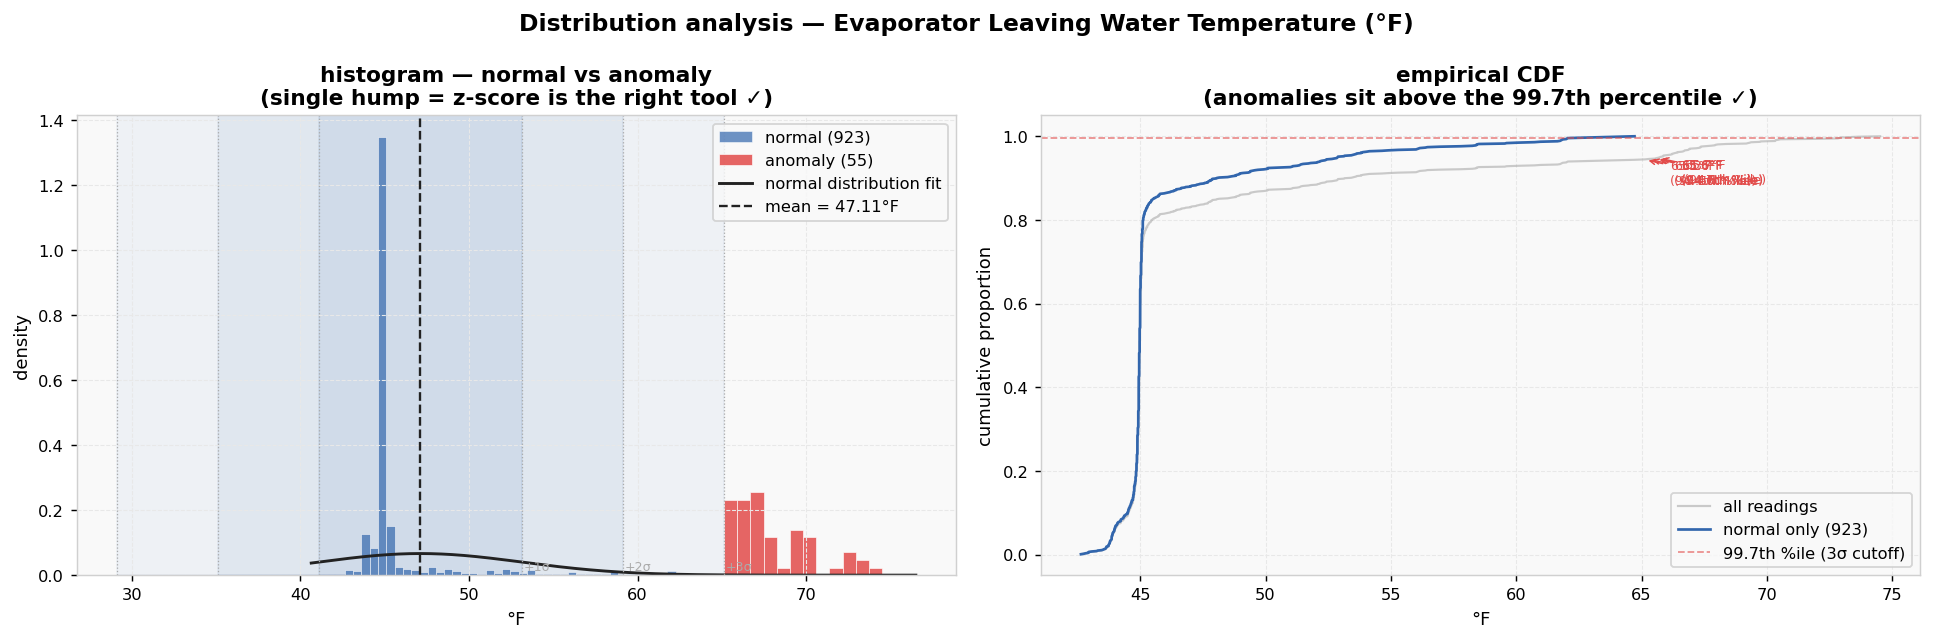

In [128]:
# ── why this graph: the time-series shows WHEN anomalies happen ───────────
# this shows WHERE in the temperature range they live
# the σ band overlay proves the z-score cutoff is mathematically justified
# if the histogram is bimodal (two humps), it means two operating modes exist
# — that would mean z-score is the wrong tool and we'd need GMM instead

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle(f"Distribution analysis — {TARGET}", fontsize=13, fontweight="bold")

mean_v = df_clean[TARGET].mean()
std_v  = df_clean[TARGET].std()
x_range = np.linspace(df_clean[TARGET].min() - 2, df_clean[TARGET].max() + 2, 400)

# ── left: histogram with σ regions shaded ────────────────────────────────
ax = axes[0]
ax.hist(normal_[TARGET],  bins=45, color=CLR_NORMAL,  alpha=0.70,
        density=True, edgecolor="white", lw=0.4, label=f"normal ({len(normal_)})")
ax.hist(anomaly_[TARGET], bins=12, color=CLR_ANOMALY, alpha=0.85,
        density=True, edgecolor="white", lw=0.4, label=f"anomaly ({len(anomaly_)})")

# overlay fitted normal curve
pdf = stats.norm.pdf(x_range, mean_v, std_v)
ax.plot(x_range, pdf, color="#222", lw=1.6, label="normal distribution fit")

# shade σ bands with annotation
sigma_configs = [(3, 0.05, "99.7%"), (2, 0.07, "95%"), (1, 0.09, "68%")]
for mult, alpha, pct_label in sigma_configs:
    ax.axvspan(mean_v - mult*std_v, mean_v + mult*std_v,
               alpha=alpha, color=CLR_NORMAL, zorder=0)
    ax.axvline(mean_v + mult*std_v, color=CLR_GREY, lw=0.7, ls=":")
    ax.axvline(mean_v - mult*std_v, color=CLR_GREY, lw=0.7, ls=":")
    ax.text(mean_v + mult*std_v + 0.1,
            ax.get_ylim()[1] * 0.01 if ax.get_ylim()[1] > 0 else 0.001,
            f"+{mult}σ", fontsize=7, color=CLR_GREY)

ax.axvline(mean_v, color="#222", lw=1.3, ls="--",
           label=f"mean = {mean_v:.2f}°F")
ax.set_xlabel("°F")
ax.set_ylabel("density")
ax.set_title("histogram — normal vs anomaly\n(single hump = z-score is the right tool ✓)")
ax.legend(fontsize=9)

# ── right: empirical CDF — shows percentile of each anomaly ───────────────
# CDF answers: "what fraction of readings are BELOW this temperature?"
# anomalies above 99.7th percentile confirm the 3σ cutoff is correct
ax2 = axes[1]
sorted_all = np.sort(df_clean[TARGET])
cdf_all    = np.arange(1, len(sorted_all)+1) / len(sorted_all)

sorted_norm = np.sort(normal_[TARGET])
cdf_norm    = np.arange(1, len(sorted_norm)+1) / len(sorted_norm)

ax2.plot(sorted_all,  cdf_all,  color=CLR_GREY,   lw=1.2, alpha=0.6,
         label="all readings")
ax2.plot(sorted_norm, cdf_norm, color=CLR_NORMAL,  lw=1.5,
         label=f"normal only ({len(normal_)})")

# mark where anomalies fall on the CDF
for val in sorted(anomaly_[TARGET])[:5]:   # first 5 unique anomaly temps
    pct = np.searchsorted(sorted_all, val) / len(sorted_all)
    ax2.annotate(f"{val:.1f}°F\n({pct*100:.1f}th %ile)",
                 xy=(val, pct), xytext=(val + 1, pct - 0.06),
                 fontsize=7, color=CLR_ANOMALY,
                 arrowprops=dict(arrowstyle="->", color=CLR_ANOMALY, lw=0.8))

ax2.axhline(0.997, color=CLR_ANOMALY, lw=1.0, ls="--", alpha=0.6,
            label="99.7th %ile (3σ cutoff)")
ax2.set_xlabel("°F")
ax2.set_ylabel("cumulative proportion")
ax2.set_title("empirical CDF\n(anomalies sit above the 99.7th percentile ✓)")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig("distribution_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

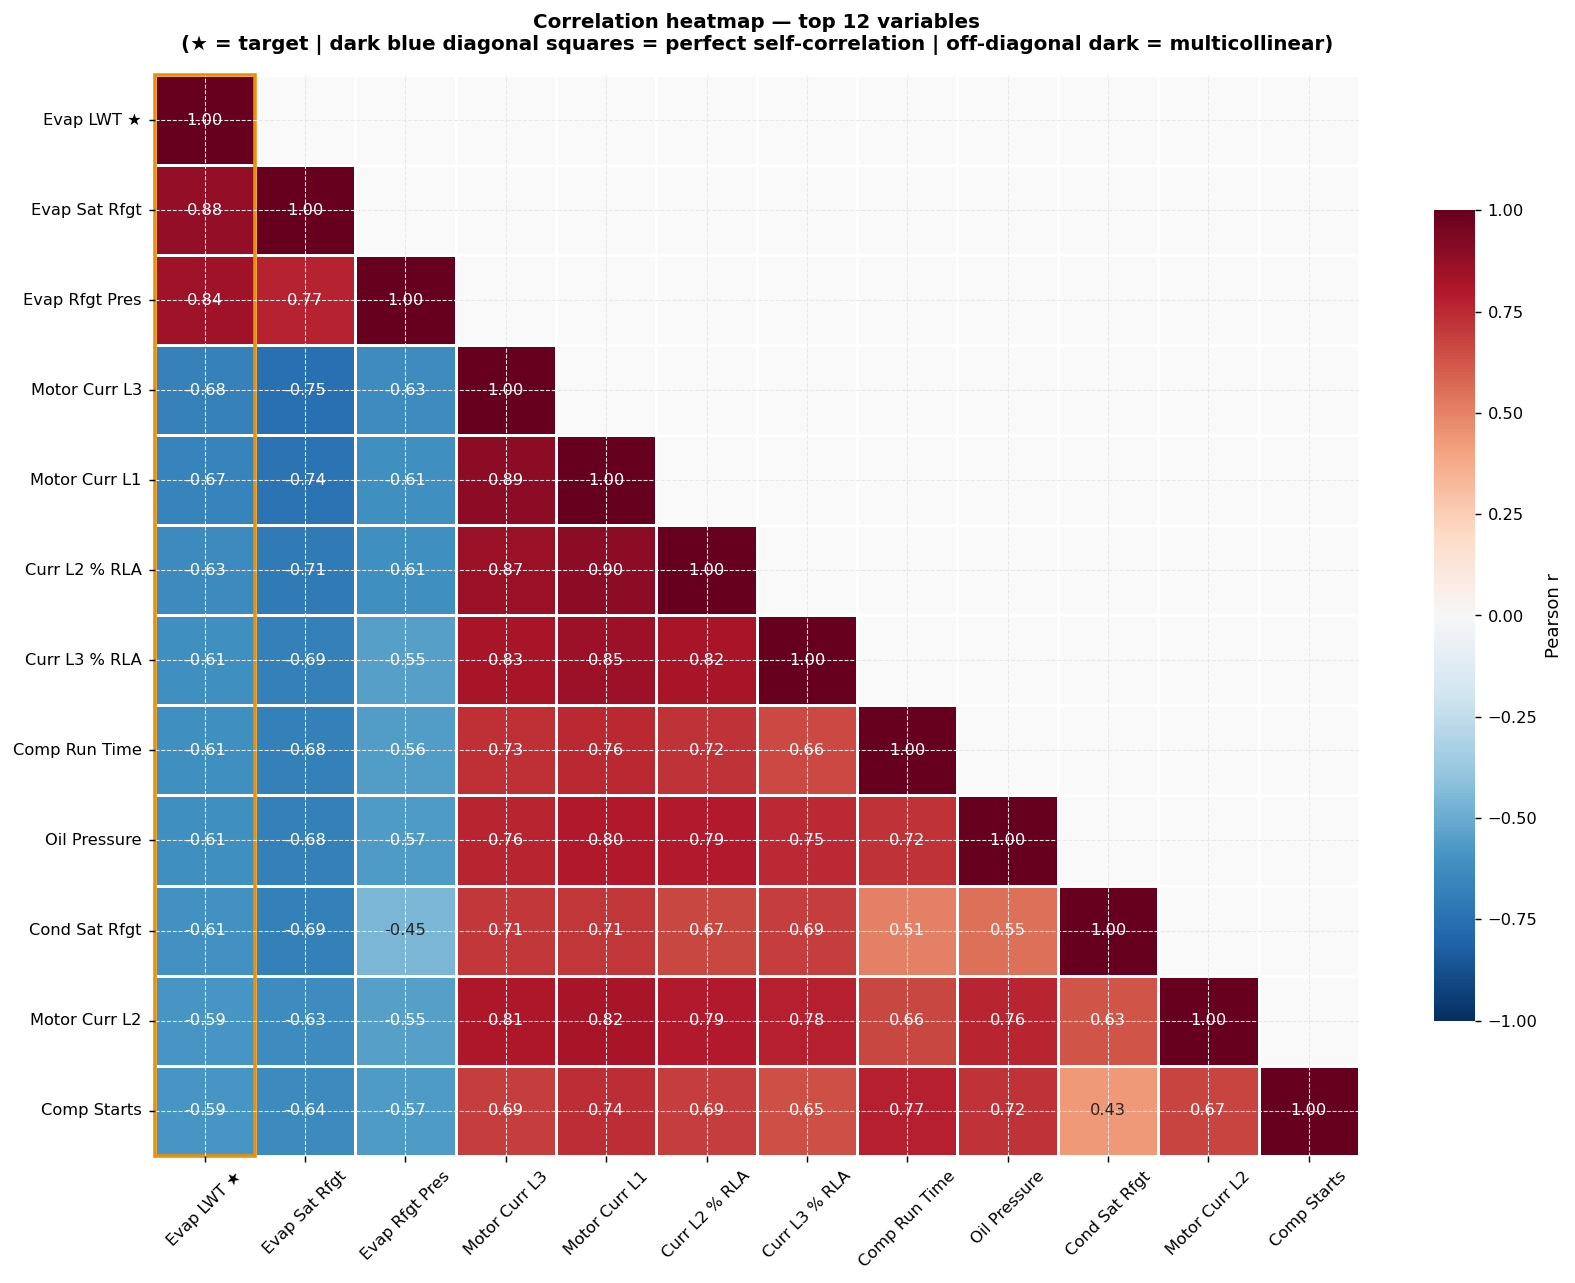

In [129]:
# ── why this graph: the bar chart shows each variable vs TARGET ───────────
# the heatmap shows every variable vs EVERY OTHER variable
# key insight: if two drivers are correlated with EACH OTHER (e.g. L1 and L2 current)
# they carry redundant info — picking one is enough for a predictive model
# dark red square between two drivers = multicollinear, don't use both in regression

top_cols = [TARGET] + corr_df.head(11)["variable"].tolist()
corr_matrix = df_clean[top_cols].corr()

short = {
    "Evaporator Leaving Water Temperature (°F)"  : "Evap LWT ★",
    "Evaporator Saturated Rfgt Temp (°F)"        : "Evap Sat Rfgt",
    "Evaporator Refrigerant Pressure (psi)"      : "Evap Rfgt Pres",
    "Starter Motor Current L3 (A)"               : "Motor Curr L3",
    "Starter Motor Current L1 (A)"               : "Motor Curr L1",
    "Starter Motor Current L2 % RLA (%)"         : "Curr L2 % RLA",
    "Starter Motor Current L3 % RLA (%)"         : "Curr L3 % RLA",
    "Compressor Running Time ( )"                : "Comp Run Time",
    "Compressor Oil Pressure (psi)"              : "Oil Pressure",
    "Condenser Saturated Rfgt Temp (°F)"         : "Cond Sat Rfgt",
    "Starter Motor Current L2 (A)"               : "Motor Curr L2",
    "Compressor Starts ( )"                      : "Comp Starts",
}
cm_labeled = corr_matrix.copy()
cm_labeled.index   = [short.get(c, c[:18]) for c in cm_labeled.index]
cm_labeled.columns = [short.get(c, c[:18]) for c in cm_labeled.columns]

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(cm_labeled, dtype=bool), k=1)

sns.heatmap(cm_labeled, mask=mask,
            annot=True, fmt=".2f",
            cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            linewidths=0.6, linecolor="white",
            ax=ax, annot_kws={"size": 9},
            cbar_kws={"shrink": 0.75, "label": "Pearson r"})

ax.set_title("Correlation heatmap — top 12 variables\n"
             "(★ = target | dark blue diagonal squares = perfect self-correlation | "
             "off-diagonal dark = multicollinear)",
             fontsize=11, fontweight="bold", pad=14)
ax.tick_params(axis="x", rotation=45, labelsize=9)
ax.tick_params(axis="y", rotation=0,  labelsize=9)

# highlight target row/column
for i, label in enumerate(cm_labeled.columns):
    if "★" in label:
        ax.add_patch(plt.Rectangle((i, 0), 1, len(cm_labeled),
                                   fill=False, edgecolor=CLR_ROLLING,
                                   lw=2, clip_on=False))

plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

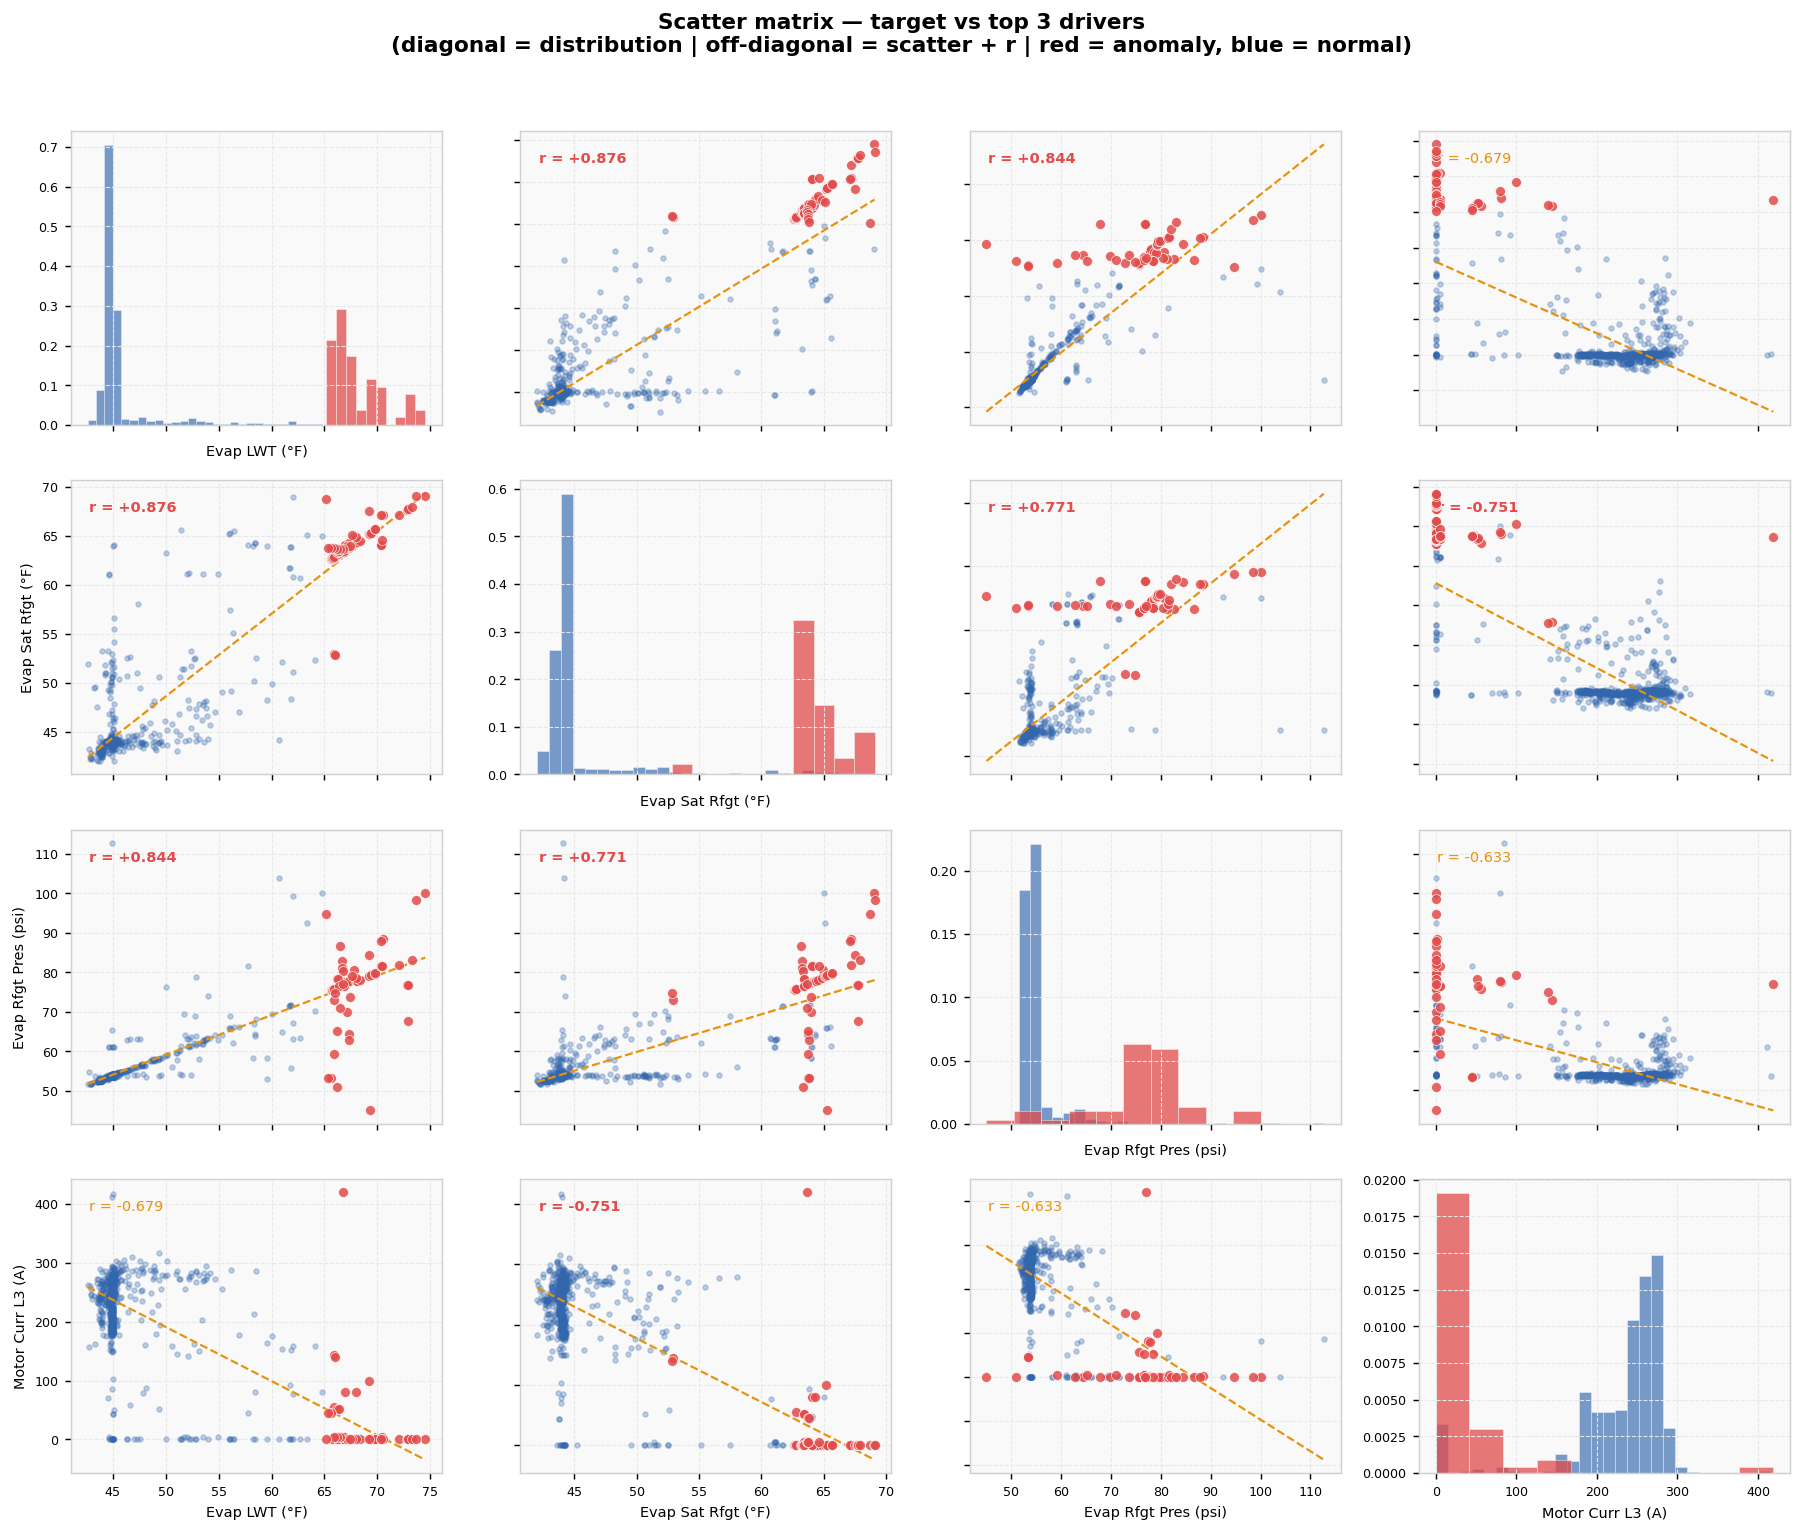

In [130]:
# ── why this graph: pearson r is a single number — this shows the raw scatter ──
# a tight diagonal cluster = high r is real and linear
# a cloud with no shape = r is near 0, no relationship
# a curved banana shape = relationship exists but it's NON-LINEAR
#   → if you see curves, pearson r is understating the actual relationship
# anomalies highlighted in red so you see if they cluster differently

top4_raw  = [TARGET,
             "Evaporator Saturated Rfgt Temp (°F)",
             "Evaporator Refrigerant Pressure (psi)",
             "Starter Motor Current L3 (A)"]
top4_lbls = ["Evap LWT (°F)", "Evap Sat Rfgt (°F)",
             "Evap Rfgt Pres (psi)", "Motor Curr L3 (A)"]

n = len(top4_raw)
fig, axes = plt.subplots(n, n, figsize=(14, 12))
fig.suptitle("Scatter matrix — target vs top 3 drivers\n"
             "(diagonal = distribution | off-diagonal = scatter + r | "
             "red = anomaly, blue = normal)",
             fontsize=12, fontweight="bold")

for i in range(n):
    for j in range(n):
        ax  = axes[i][j]
        ci  = top4_raw[i]
        cj  = top4_raw[j]
        li  = top4_lbls[i]
        lj  = top4_lbls[j]

        if i == j:
            # diagonal — overlapping KDE-style histogram
            ax.hist(df_clean.loc[~df_clean["is_anomaly"], ci],
                    bins=28, color=CLR_NORMAL, alpha=0.65,
                    density=True, edgecolor="white", lw=0.3)
            ax.hist(df_clean.loc[ df_clean["is_anomaly"], ci],
                    bins=10, color=CLR_ANOMALY, alpha=0.75,
                    density=True, edgecolor="white", lw=0.3)
            ax.set_xlabel(li, fontsize=8)
        else:
            # scatter: normal points first, anomalies on top
            ax.scatter(df_clean.loc[~df_clean["is_anomaly"], cj],
                       df_clean.loc[~df_clean["is_anomaly"], ci],
                       color=CLR_NORMAL, s=7, alpha=0.28, zorder=2)
            ax.scatter(df_clean.loc[ df_clean["is_anomaly"], cj],
                       df_clean.loc[ df_clean["is_anomaly"], ci],
                       color=CLR_ANOMALY, s=30, alpha=0.85, zorder=5,
                       marker="o", edgecolors="white", linewidths=0.4)

            # regression line
            tmp = df_clean[[ci, cj]].dropna()
            if len(tmp) > 10 and tmp[cj].std() > 0:
                m, b, r_val, _, _ = stats.linregress(tmp[cj], tmp[ci])
                x_line = np.linspace(tmp[cj].min(), tmp[cj].max(), 100)
                ax.plot(x_line, m*x_line + b,
                        color=CLR_ROLLING, lw=1.2, ls="--", zorder=3)

                # annotate r in top-left corner
                fc   = CLR_ANOMALY if abs(r_val) > 0.7 else \
                       CLR_ROLLING  if abs(r_val) > 0.5 else "#666"
                bold = "bold" if abs(r_val) > 0.7 else "normal"
                ax.text(0.05, 0.93, f"r = {r_val:+.3f}",
                        transform=ax.transAxes, fontsize=8,
                        color=fc, fontweight=bold, va="top")

            if j == 0: ax.set_ylabel(li, fontsize=8)
            if i == n-1: ax.set_xlabel(lj, fontsize=8)

        ax.tick_params(labelsize=7)
        # remove inner tick labels to reduce clutter
        if j > 0 and i != j: ax.set_yticklabels([])
        if i < n-1:           ax.set_xticklabels([])

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("scatter_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

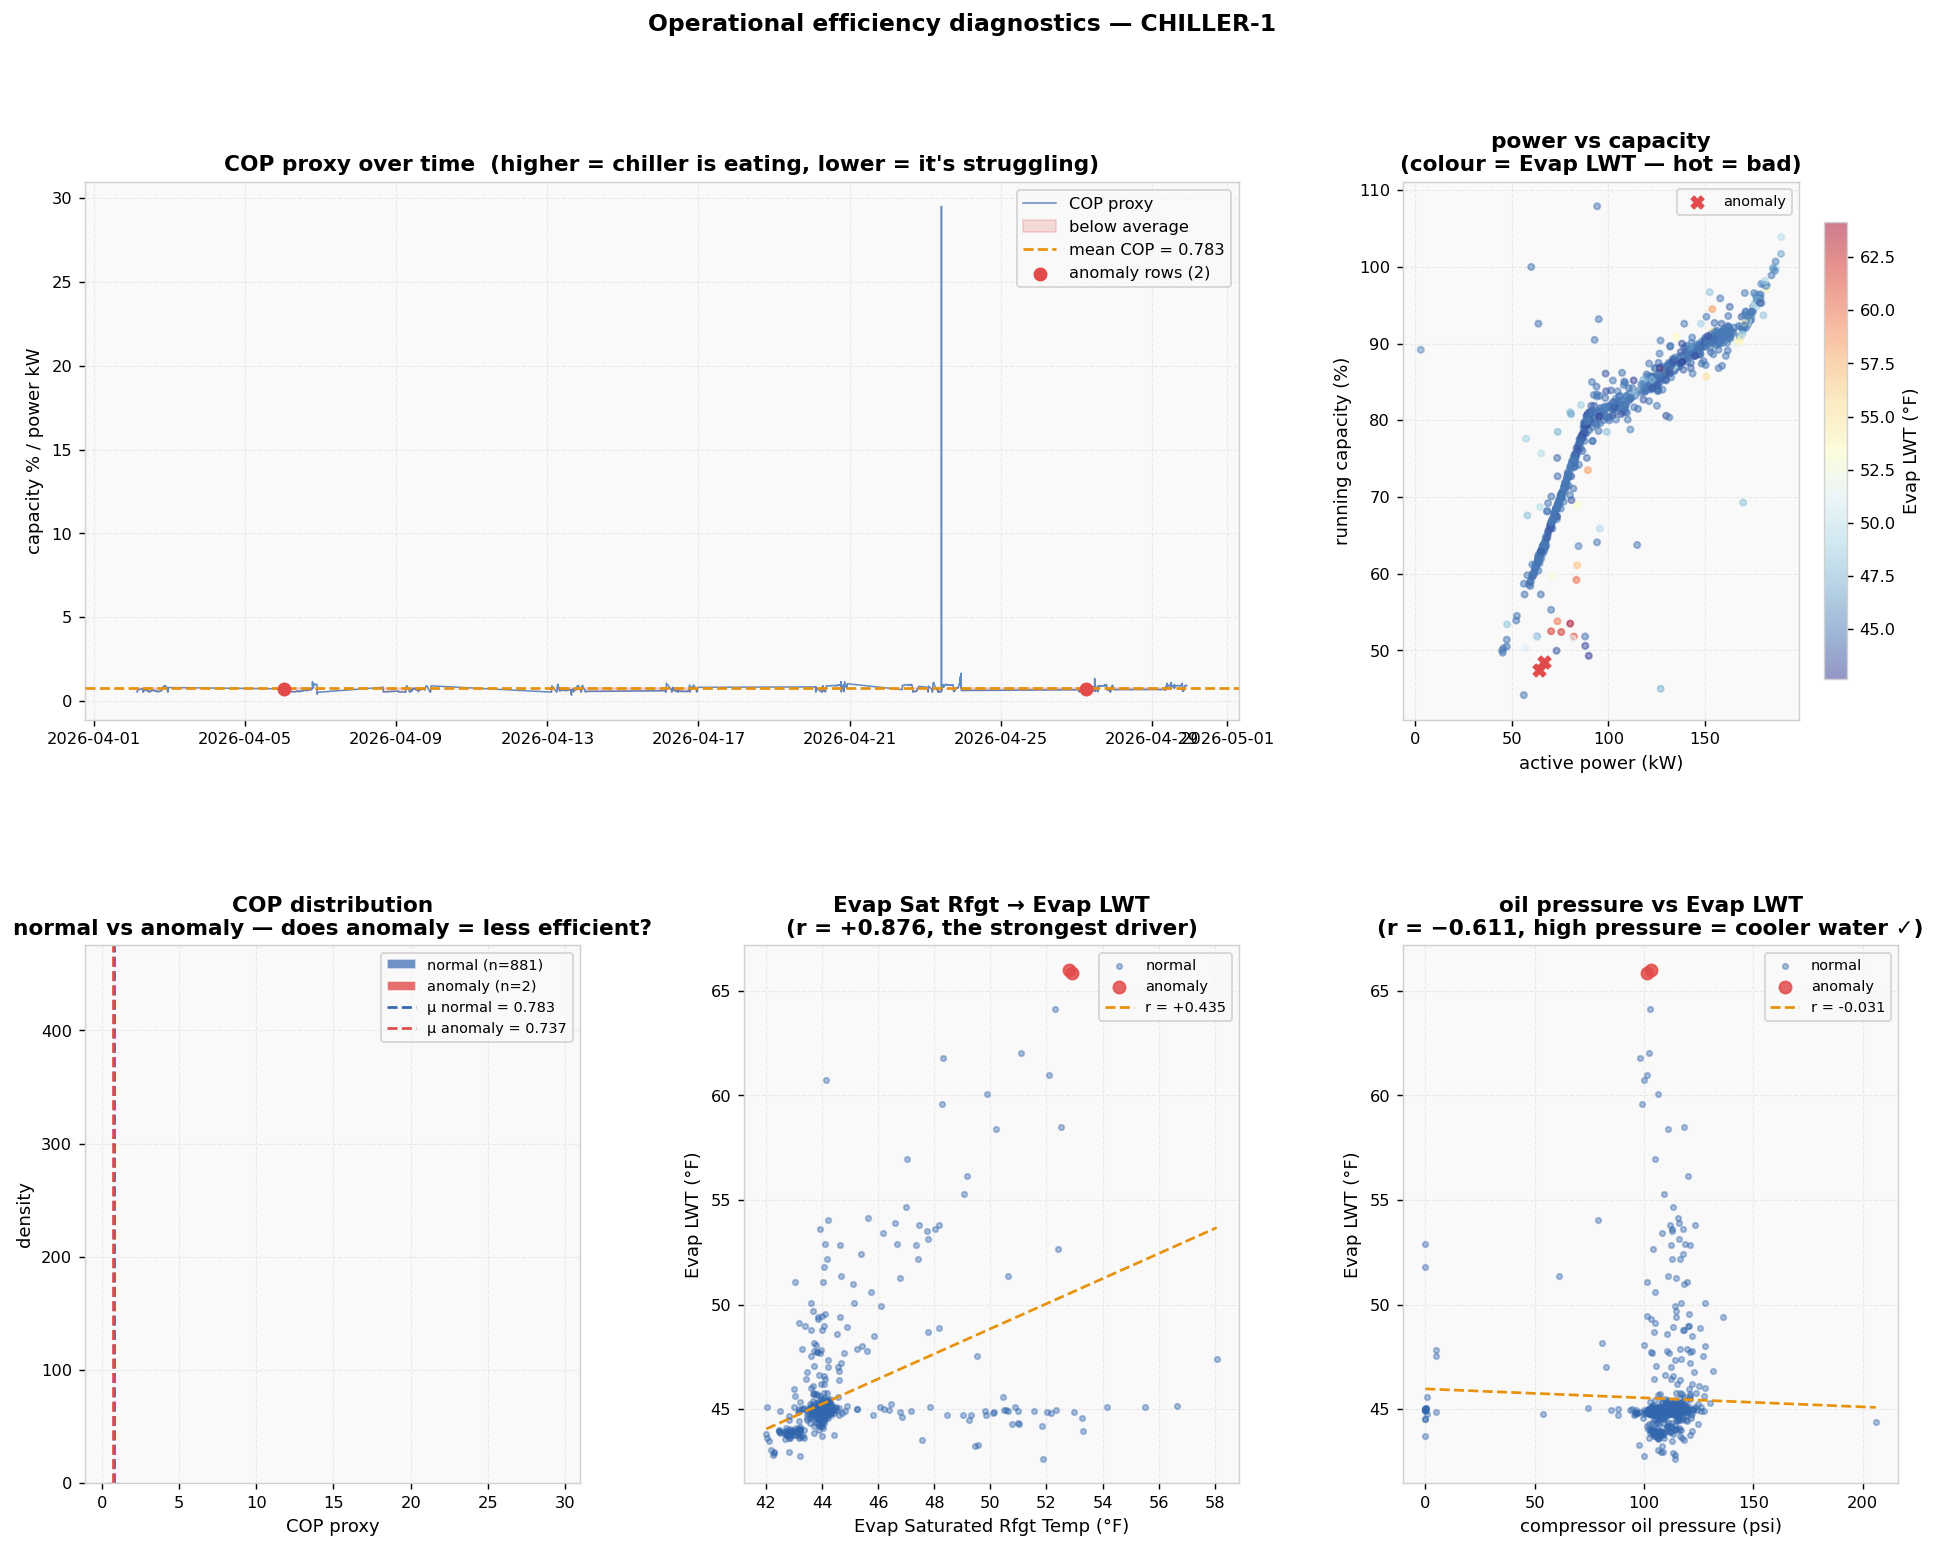

<Figure size 832x624 with 0 Axes>

In [131]:
# ── why this graph: anomaly detection tells you WHAT is weird ─────────────
# efficiency analysis tells you WHETHER it's COSTING YOU anything
# COP proxy = capacity / power — higher is better
# the key question: do anomaly timestamps have worse COP?
# if yes = those high-temp events are literally costing energy
# if no  = the anomaly is a sensor artifact, not a real performance issue

eff = df_clean[[
    "Actual Running Capacity (%)",
    "CHILLER-1 ACTIVE POWER (W) (kW)",
    TARGET,
    "Compressor Oil Pressure (psi)",
    "Condenser Saturated Rfgt Temp (°F)",
    "Evaporator Saturated Rfgt Temp (°F)",
    "DateTime", "is_anomaly"
]].dropna().copy()

eff["COP_proxy"] = (eff["Actual Running Capacity (%)"] /
                    eff["CHILLER-1 ACTIVE POWER (W) (kW)"].replace(0, np.nan))
eff = eff.dropna(subset=["COP_proxy"])

cop_normal  = eff.loc[~eff["is_anomaly"], "COP_proxy"]
cop_anomaly = eff.loc[ eff["is_anomaly"], "COP_proxy"]

fig = plt.figure(figsize=(18, 13))
gs = fig.add_gridspec(2, 3, hspace=0.42, wspace=0.33)
fig.suptitle("Operational efficiency diagnostics — CHILLER-1", fontsize=13, fontweight="bold")

# ── 1. COP proxy over time ────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :2])
ax1.plot(eff["DateTime"], eff["COP_proxy"],
         color=CLR_NORMAL, lw=0.85, alpha=0.75, label="COP proxy", zorder=2)
ax1.fill_between(
    eff["DateTime"],
    eff["COP_proxy"],
    eff["COP_proxy"].mean(),
    where=eff["COP_proxy"].lt(eff["COP_proxy"].mean()).to_numpy(),
    alpha=0.18,
    color=CLR_ANOMALY,
    label="below average",
)
ax1.axhline(eff["COP_proxy"].mean(), color=CLR_ROLLING, lw=1.5, ls="--",
            label=f"mean COP = {eff['COP_proxy'].mean():.3f}", zorder=4)
ax1.scatter(eff.loc[ eff["is_anomaly"], "DateTime"],
            eff.loc[ eff["is_anomaly"], "COP_proxy"],
            color=CLR_ANOMALY, s=45, zorder=6,
            label=f"anomaly rows ({eff['is_anomaly'].sum()})")
ax1.set_ylabel("capacity % / power kW")
ax1.set_title("COP proxy over time  (higher = chiller is eating, lower = it's struggling)")
ax1.legend(fontsize=9, loc="upper right")

# ── 2. Power vs Capacity scatter coloured by Evap LWT ────────────────────
ax2 = fig.add_subplot(gs[0, 2])
sc = ax2.scatter(eff.loc[~eff["is_anomaly"], "CHILLER-1 ACTIVE POWER (W) (kW)"],
                 eff.loc[~eff["is_anomaly"], "Actual Running Capacity (%)"],
                 c=eff.loc[~eff["is_anomaly"], TARGET],
                 cmap="RdYlBu_r", s=12, alpha=0.5, zorder=2)
ax2.scatter(eff.loc[ eff["is_anomaly"], "CHILLER-1 ACTIVE POWER (W) (kW)"],
            eff.loc[ eff["is_anomaly"], "Actual Running Capacity (%)"],
            color=CLR_ANOMALY, s=55, zorder=5, marker="X",
            linewidths=0.5, label="anomaly")
plt.colorbar(sc, ax=ax2, label="Evap LWT (°F)", shrink=0.85)
ax2.set_xlabel("active power (kW)")
ax2.set_ylabel("running capacity (%)")
ax2.set_title("power vs capacity\n(colour = Evap LWT — hot = bad)")
ax2.legend(fontsize=8)

# ── 3. COP distribution: normal vs anomaly ────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
ax3.hist(cop_normal,  bins=35, color=CLR_NORMAL,  alpha=0.70,
         density=True, edgecolor="white", label=f"normal (n={len(cop_normal)})")
ax3.hist(cop_anomaly, bins=12, color=CLR_ANOMALY, alpha=0.80,
         density=True, edgecolor="white", label=f"anomaly (n={len(cop_anomaly)})")
ax3.axvline(cop_normal.mean(),  color=CLR_NORMAL,  lw=1.5, ls="--",
            label=f"μ normal = {cop_normal.mean():.3f}")
ax3.axvline(cop_anomaly.mean(), color=CLR_ANOMALY, lw=1.5, ls="--",
            label=f"μ anomaly = {cop_anomaly.mean():.3f}")
ax3.set_xlabel("COP proxy")
ax3.set_ylabel("density")
ax3.set_title("COP distribution\nnormal vs anomaly — does anomaly = less efficient?")
ax3.legend(fontsize=8)

# ── 4. Evap sat rfgt temp vs Evap LWT (the core refrigerant relationship) ─
ax4 = fig.add_subplot(gs[1, 1])
ax4.scatter(eff.loc[~eff["is_anomaly"], "Evaporator Saturated Rfgt Temp (°F)"],
            eff.loc[~eff["is_anomaly"], TARGET],
            color=CLR_NORMAL, s=9, alpha=0.4, label="normal", zorder=2)
ax4.scatter(eff.loc[ eff["is_anomaly"], "Evaporator Saturated Rfgt Temp (°F)"],
            eff.loc[ eff["is_anomaly"], TARGET],
            color=CLR_ANOMALY, s=45, alpha=0.85, zorder=5, label="anomaly")

# fit regression line
tmp = eff[["Evaporator Saturated Rfgt Temp (°F)", TARGET]].dropna()
m, b, r_v, _, _ = stats.linregress(tmp["Evaporator Saturated Rfgt Temp (°F)"], tmp[TARGET])
x_l = np.linspace(tmp["Evaporator Saturated Rfgt Temp (°F)"].min(),
                  tmp["Evaporator Saturated Rfgt Temp (°F)"].max(), 200)
ax4.plot(x_l, m*x_l + b, color=CLR_ROLLING, lw=1.5, ls="--",
         label=f"r = {r_v:+.3f}")
ax4.set_xlabel("Evap Saturated Rfgt Temp (°F)")
ax4.set_ylabel("Evap LWT (°F)")
ax4.set_title("Evap Sat Rfgt → Evap LWT\n(r = +0.876, the strongest driver)")
ax4.legend(fontsize=8)

# ── 5. Oil pressure vs Evap LWT (health indicator) ────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
ax5.scatter(eff.loc[~eff["is_anomaly"], "Compressor Oil Pressure (psi)"],
            eff.loc[~eff["is_anomaly"], TARGET],
            color=CLR_NORMAL, s=9, alpha=0.4, label="normal", zorder=2)
ax5.scatter(eff.loc[ eff["is_anomaly"], "Compressor Oil Pressure (psi)"],
            eff.loc[ eff["is_anomaly"], TARGET],
            color=CLR_ANOMALY, s=45, alpha=0.85, zorder=5, label="anomaly")
tmp2 = eff[["Compressor Oil Pressure (psi)", TARGET]].dropna()
m2, b2, r_v2, _, _ = stats.linregress(tmp2["Compressor Oil Pressure (psi)"], tmp2[TARGET])
x_l2 = np.linspace(tmp2["Compressor Oil Pressure (psi)"].min(),
                   tmp2["Compressor Oil Pressure (psi)"].max(), 200)
ax5.plot(x_l2, m2*x_l2 + b2, color=CLR_ROLLING, lw=1.5, ls="--",
         label=f"r = {r_v2:+.3f}")
ax5.set_xlabel("compressor oil pressure (psi)")
ax5.set_ylabel("Evap LWT (°F)")
ax5.set_title("oil pressure vs Evap LWT\n(r = −0.611, high pressure = cooler water ✓)")
ax5.legend(fontsize=8)

plt.show()
plt.savefig("efficiency_diagnostics.png", dpi=150, bbox_inches="tight")

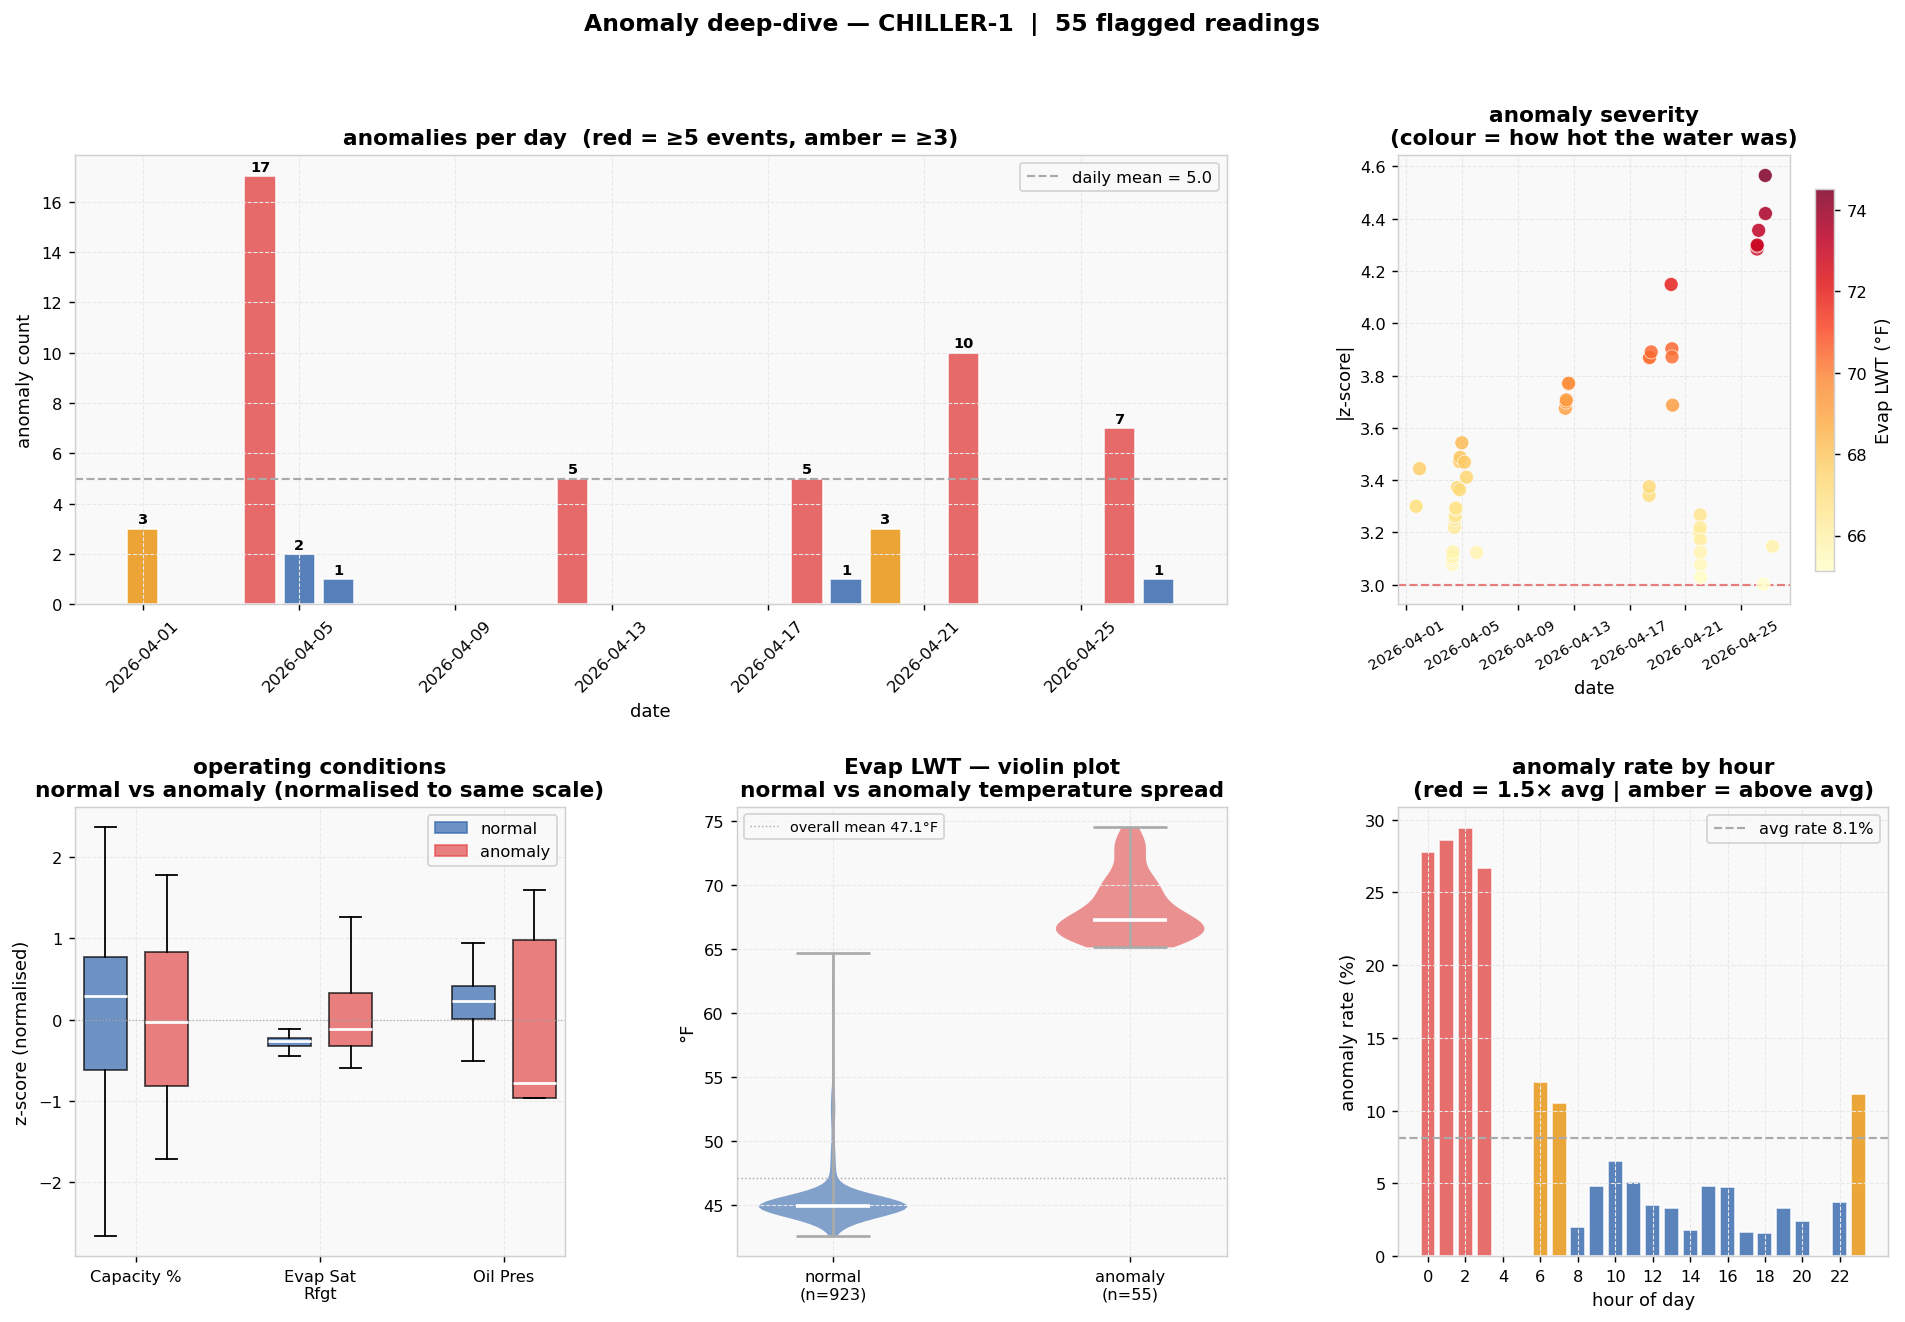

<Figure size 832x624 with 0 Axes>

In [132]:
# ── why this graph: "55 anomalies" is a count — this makes it actionable ──
# shows: which dates had anomalies, how severe they were, and
# whether they correlate with specific operating conditions
# the heatmap by day shows if anomalies are recurring on specific days
# (a recurring pattern = systematic issue, not a one-off event)

from matplotlib import gridspec


anom = df_clean[df_clean["is_anomaly"]].copy()
anom["date"]  = anom["DateTime"].dt.date
anom["hour"]  = anom["DateTime"].dt.hour

fig = plt.figure(figsize=(18, 11))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)
fig.suptitle("Anomaly deep-dive — CHILLER-1  |  55 flagged readings",
             fontsize=13, fontweight="bold")

# ── 1. Anomaly count per day ───────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :2])
daily_counts = anom.groupby("date").size()
colors_daily = [CLR_ANOMALY if c >= 5 else CLR_ROLLING if c >= 3 else CLR_NORMAL
                for c in daily_counts.values]
bars = ax1.bar(daily_counts.index, daily_counts.values,
               color=colors_daily, alpha=0.82, edgecolor="white")
ax1.axhline(daily_counts.mean(), color=CLR_GREY, lw=1.2, ls="--",
            label=f"daily mean = {daily_counts.mean():.1f}")
for bar, val in zip(bars, daily_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 0.1,
             str(val), ha="center", va="bottom", fontsize=8, fontweight="bold")
ax1.set_xlabel("date")
ax1.set_ylabel("anomaly count")
ax1.set_title("anomalies per day  (red = ≥5 events, amber = ≥3)")
ax1.tick_params(axis="x", rotation=45)
ax1.legend(fontsize=9)

# ── 2. Anomaly severity (z-score) over time ───────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
sc2 = ax2.scatter(anom["DateTime"], anom["z_score"],
                  c=anom[TARGET], cmap="YlOrRd",
                  s=60, alpha=0.85, zorder=5,
                  edgecolors="white", linewidths=0.4)
ax2.axhline(THRESHOLD, color=CLR_ANOMALY, lw=1.2, ls="--", alpha=0.7)
plt.colorbar(sc2, ax=ax2, label="Evap LWT (°F)", shrink=0.85)
ax2.set_xlabel("date")
ax2.set_ylabel("|z-score|")
ax2.set_title("anomaly severity\n(colour = how hot the water was)")
ax2.tick_params(axis="x", rotation=30, labelsize=8)

# ── 3. What else was happening during anomalies — box plots ───────────────
ax3 = fig.add_subplot(gs[1, 0])
compare_cols = ["Actual Running Capacity (%)",
                "Evaporator Saturated Rfgt Temp (°F)",
                "Compressor Oil Pressure (psi)"]
compare_cols = [c for c in compare_cols if c in df_clean.columns]

# z-score normalise each variable so they're on the same scale for comparison
plot_data_n = [stats.zscore(df_clean.loc[~df_clean["is_anomaly"], c].dropna())
               for c in compare_cols]
plot_data_a = [stats.zscore(df_clean.loc[ df_clean["is_anomaly"], c].dropna())
               for c in compare_cols]

positions_n = [1, 4, 7]
positions_a = [2, 5, 8]
short_lbls  = ["Capacity %", "Evap Sat\nRfgt", "Oil Pres"]

bp_n = ax3.boxplot(plot_data_n, positions=positions_n, widths=0.7,
                   patch_artist=True, showfliers=False,
                   medianprops=dict(color="white", lw=1.5))
bp_a = ax3.boxplot(plot_data_a, positions=positions_a, widths=0.7,
                   patch_artist=True, showfliers=False,
                   medianprops=dict(color="white", lw=1.5))

for patch in bp_n["boxes"]: patch.set(facecolor=CLR_NORMAL,  alpha=0.7)
for patch in bp_a["boxes"]: patch.set(facecolor=CLR_ANOMALY, alpha=0.7)

ax3.set_xticks([1.5, 4.5, 7.5])
ax3.set_xticklabels(short_lbls, fontsize=9)
ax3.set_ylabel("z-score (normalised)")
ax3.set_title("operating conditions\nnormal vs anomaly (normalised to same scale)")
ax3.axhline(0, color=CLR_GREY, lw=0.7, ls=":")
legend_bp = [plt.matplotlib.patches.Patch(color=CLR_NORMAL,  alpha=0.7, label="normal"),
             plt.matplotlib.patches.Patch(color=CLR_ANOMALY, alpha=0.7, label="anomaly")]
ax3.legend(handles=legend_bp, fontsize=9)

# ── 4. Anomaly temperature range vs normal ────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
violin_data = [normal_[TARGET].values, anomaly_[TARGET].values]
vp = ax4.violinplot(violin_data, positions=[1, 2],
                    showmedians=True, showextrema=True)
for i, (body, color) in enumerate(zip(vp["bodies"], [CLR_NORMAL, CLR_ANOMALY])):
    body.set(facecolor=color, alpha=0.6)
vp["cmedians"].set(color="white", lw=2)
vp["cmaxes"].set(color=CLR_GREY)
vp["cmins"].set(color=CLR_GREY)
vp["cbars"].set(color=CLR_GREY)
ax4.set_xticks([1, 2])
ax4.set_xticklabels(["normal\n(n=923)", "anomaly\n(n=55)"], fontsize=9)
ax4.set_ylabel("°F")
ax4.set_title("Evap LWT — violin plot\nnormal vs anomaly temperature spread")
ax4.axhline(mean_v, color=CLR_GREY, lw=0.8, ls=":", label=f"overall mean {mean_v:.1f}°F")
ax4.legend(fontsize=8)

# ── 5. Hour-of-day pattern: when do anomalies cluster? ────────────────────
ax5 = fig.add_subplot(gs[1, 2])
hour_counts = anom.groupby("hour").size().reindex(range(24), fill_value=0)
hour_total  = df_clean.groupby(df_clean["DateTime"].dt.hour).size()
hour_rate   = (hour_counts / hour_total * 100).fillna(0)

bar_colors_h = [CLR_ANOMALY if v > hour_rate.mean()*1.5 else
                CLR_ROLLING  if v > hour_rate.mean() else
                CLR_NORMAL   for v in hour_rate.values]
ax5.bar(hour_rate.index, hour_rate.values,
        color=bar_colors_h, alpha=0.8, edgecolor="white")
ax5.axhline(hour_rate.mean(), color=CLR_GREY, lw=1.2, ls="--",
            label=f"avg rate {hour_rate.mean():.1f}%")
ax5.set_xlabel("hour of day")
ax5.set_ylabel("anomaly rate (%)")
ax5.set_title("anomaly rate by hour\n(red = 1.5× avg | amber = above avg)")
ax5.set_xticks(range(0, 24, 2))
ax5.legend(fontsize=9)

plt.show()
plt.savefig("anomaly_deep_dive.png", dpi=150, bbox_inches="tight")